In [1]:
'''

Read a set of datafiles, each containing datawords obtained by sending a particular csa_testpulse 
simultaneously into one channel of each chip's adc (iterating from channel 0 to channel 63 
simultaneously on each chip).

Each datafile has a different value of the csa_testpuls dac ranging from 88 to 148 in increments 
of 20. 

Gain is measured as the slope of a line fit through the resulting mean datawords 
versus the input voltage for each dac level

'''

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math

from tqdm import tqdm
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from scipy import stats
from scipy.stats import trim_mean
from statistics import mean, mode, stdev
from pathlib import Path
from datetime import datetime

##########################################################
# Initialize parameters  
##########################################################

# tiles were tested in 3 sets of 10-tile
sets = [2,3,4]
#sets = [3]

# cold data sets 2-4
file_sets = [ ["/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_88dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5", 
               "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_108dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5", 
               "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_128dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5",
               "/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_148dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5"               
              ],
              ["/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_gain_88dac_set3_9tiles_2200s_220vref_no_hotchan_1.hdf5", 
               "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_gain_108dac_set3_9tiles_2200s_220vref_no_hotchan_1.hdf5", 
               "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_gain_128dac_set3_9tiles_2200s_220vref_no_hotchan_1.hdf5",
               "/data/v3/10x16/set3_10_tile_tests_20260505/data/cold/packet-cold_gain_148dac_set3_9tiles_2200s_220vref_no_hotchan_1.hdf5"               
              ],
              ["/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_gain_88dac_set4_10tiles_2200s_no_hotchan_1.hdf5",
               "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_gain_108dac_set4_10tiles_2200s_no_hotchan_1.hdf5",
               "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_gain_128dac_set4_10tiles_2200s_no_hotchan_1.hdf5",
               "/data/v3/10x16/set4_10_tile_tests_20260512/data/cold/packet-cold_gain_148dac_set4_10tiles_2200s_no_hotchan_1.hdf5",
              ]
        ]

# Set 2 consisted of 10 tiles. Tiles 5-10 of sets 3 and 4 are the same. The list below uses the data from set 4 for these tiles. 
# The 1st tile of set 3 was bad (it continued to fail to hydra network) so gain was not measured.
tile_sets = [ [1,2,3,4,5,6,7,8,9,10],
              [2,3,4],
              [1,2,3,4,5,6,7,8,9,10]
            ]

'''
tile_sets = [ [1],
              [],
              []]
'''

chip_serial_number_list = [ ['4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770' ],
                            ['', '4k03591', '4k03936', '4k00607' ],
                            ['4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496' ] 
                          ]

# certain channels have poor measurements, specifically those near the analogue monitor. Omitting them
# avoids flooding the results with issues that are unrelated to gain. Channel 63 was omitted because
# occasionally the run ended before the last channel was tested
omitted_channels = [56,57,58,59,63]

# certain chips may have been disabled due to hydra (or other) issues. Omitting them avoids flooding the
# results with issues that are unrelated to gain
omitted_chips = []

# the dacs listed here must match the dac settings of the files you wish to analyze
dacs = [88, 108, 128, 148]
high_word = [620, 620, 620, 700]
low_word  = [420, 420, 420, 420]

# test setup
temp = "cold"
vdda = 2066
n_iterations = 6
capacitance_test_pulse = 40e-15
n_dacs = len(dacs)
v_ref_dac = 220

n_stdev = 3

# Setting verbose = True will print out various pieces of chip-level or packet-level information 
verbose = False

n_good_to_graph = 5
n_bad_to_graph  = 5
n_good, n_bad = 0,0

# initialize
all_gain, all_rsqr = [], []
n_all_bad_channels = 0
n_all_channels = 0
ntiles = 0

# record the worst fit measurement from each channel
worst_fit_measurement = []

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp'

In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20],
        [21,22,23,24],
        [25,26,27,28],
        [29,30,31,32],
        [33,34,35,36],
        [37,38,39,40]
        ]
    
    return io_ch_per_tile[tile]


In [3]:
'''
    Calculate the mean and stdev of datawords for the given dac level. Filter out low words
    that indicate self-trigger packets

'''

def get_mean_stdev(packets, dac):

    global dacs, mean_chip, mean_chan, pkt_count, omitted_chan, omitted_chips
    
    dac_index = dacs.index(dac)

    words = packets['dataword'][:]
    
    # calculate means per chip and channel
    for chip in range(11,171):

        if chip in omitted_chips:
            print(f"Chip {chip} was initialized to be omitted")
            continue

        # mask for chip
        chip_mask = packets['chip_id'] == chip
        chip_pkts = packets[chip_mask]
        chip_word  = chip_pkts['dataword'][:]

        # do not consider words that appear to be from self-trigger packets
        in_range_words  = [x for x in chip_word if x > low_word[dac_index]]
        
        if len(in_range_words) > 2:        
            mean_chip[chip][dac_index] = np.mean(in_range_words)
        else:
            if verbose:
                print(f"There are no in-range words for chip {chip}")
            continue
            
        for chan in range(64):

            if chan in omitted_channels:
                continue
            
            # mask for channel    
            chan_mask = chip_pkts['channel_id'] == chan
            chan_pkts = chip_pkts[chan_mask]
            chan_word  = chan_pkts['dataword'][:]
            in_range_words  = [x for x in chan_word if x > low_word[dac_index]]
            
            if len(in_range_words) == 0:
                if verbose:
                    print(f"There are no in-range words for chip-chan {chip}-{chan} dac-level {dac}. # pkts = {len(chan_word)}")
                continue
            
            mean_chan[chip][chan][dac_index] = np.mean(in_range_words)
            pkt_count[chip][chan] += pkt_count[chip][chan] + len(in_range_words)       
            if pkt_count[chip][chan] > 1E4 and verbose:
                print(f"\nChip-Chan {chip}-{chan} had too many packets {pkt_count[chip][chan]} and may be hot")
    
    return
    

In [4]:
def find_good_words(setn,tile_pkts, dac_index):

    global low_word, high_word, n_bad_words, omitted_channels
    
    # check for tiles with no data    
    if len(tile_pkts) ==0: 
        print(f'There are no data packets for tile {tile}')        
        return
        
    # remove data packets with dataword = 0
    non_zero_pkts = tile_pkts[tile_pkts['dataword'] != 0]        
        
    non_zero_words = non_zero_pkts['dataword'][:]
    non_zero_chips = non_zero_pkts['chip_id'][:]
    non_zero_chans = non_zero_pkts['channel_id'][:]

    # look for bad chip ids
    n_bad_chip_id = sum(1 for x in non_zero_chips if x < 11 or x > 170)
    
    # mask for words that are out of the expected range
    low_word_mask   = non_zero_words < low_word[dac_index]
    low_words       = non_zero_words[low_word_mask]

    high_word_mask  = non_zero_words > high_word[dac_index]
    high_words      = non_zero_words[high_word_mask]
    high_word_pkts  = non_zero_pkts[high_word_mask]
    
    if len(high_words) > 0: 
        print(f"\nHigh Word Statistics:")
        print(f"\tlowest out-of-range high-word = {min(high_words)}")
        high_chips = list(dict.fromkeys(high_word_pkts['chip_id'][:]))
        high_chans = list(dict.fromkeys(high_word_pkts['channel_id'][:]))
        print(f"\thigh-word chips   : {high_chips}")
        print(f"\thigh-word channels: {high_chans}")
        
    bad_word_mask   = low_word_mask + high_word_mask
    bad_words       = non_zero_words[bad_word_mask]
        
    bad_word_chips = non_zero_chips[bad_word_mask]
    bad_word_chans = non_zero_chans[bad_word_mask]

    for i in range(len(bad_word_chips)):
        n_bad_words[bad_word_chips[i]][bad_word_chans[i]] +=1

    for chip in range(11,171):
        for chan in range(63):
            if n_bad_words[chip][chan] > 100 and chan not in omitted_channels and verbose:
                print(f"\nChip-Chan {chip}-{chan} had {n_bad_words[chip][chan]} bad words")
        
    # mask for in-range words
    good_word_mask = np.logical_not(bad_word_mask)
    good_words = non_zero_words[good_word_mask]
    good_word_pkts = non_zero_pkts[good_word_mask]
        
    mean_word = np.mean(good_words)

    if verbose:
        print(f"\nMean In-range word for dac {dac} = {mean_word:.0f}\n")

    if dac == 128:
        
        fig, ax = plt.subplots(1,2, figsize=(14, 3))

        ax[0].scatter(non_zero_chans, non_zero_words, alpha = 0.06, color = 'g')
        ax[0].set_title(f'Data words for Dac level {dac} (In-range Mean {mean_word:.0f})\n {temp} test of  v3a Set {setn} Tile #{tile} ({chip_serial_number})')
        ax[0].set_xlabel(f'Channel')
        ax[0].set_ylabel(f'Dataword')
    
        ax[1].scatter(bad_word_chans, bad_word_chips, alpha = 0.08)
        ax[1].set_title(f'Location of Out-of-Range Words (dac {dac})\n {temp} test of  v3a Set {setn} Tile #{tile} ({chip_serial_number})')
        ax[1].set_xlabel(f'Channel')   
        ax[1].set_ylabel(f'Chip')

        plt.show
            
    return good_word_pkts


In [5]:
'''
Read data from the variety of dac-level files, remove zero datawords and call the function
that calculates mean and stdev of datawords.
'''

def get_data(setn, files, tile):
    
    global chip_serial_number, temp, total_livetime, dac
    
    
    # read packet data from each file (distinguished by dac level)
    for filename in files:

        if '_68dac' in filename:
            dac = 68
        elif '_88dac' in filename:
            dac = 88
        elif '_108dac' in filename:
            dac = 108            
        elif '_128dac' in filename:
            dac = 128
        elif '_148dac' in filename:
            dac = 148
        elif '_168dac' in filename:
            dac = 168            
        else:
            print(f"Problem: the dac setting was not indicated in the file name")        

        dac_index = dacs.index(dac)
               
        # read packets from the file
        f = h5py.File(filename, 'r')
        packets = f['packets'][:]

        # create arrays of data packets
        data_mask = f['packets'][:]['packet_type']  == 1
        data_pkts = packets[data_mask]

        # determine the runtime of the file
        unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
        livetime = np.max(unixtime)-np.min(unixtime)        

        total_livetime = livetime
            
        print(f"\t{len(data_pkts):,} data packets using dac {dac} gathered over {livetime}s in \n\t{filename}")   

        tile_pkts = tile_mask(data_pkts, tile)

        good_word_pkts = find_good_words(setn, tile_pkts, dac_index)

        get_mean_stdev(good_word_pkts, dac)
    
    return

In [6]:
def tile_mask(data_pkts, tile):
    
    # get a list of the io_channels that could be enabled for a given tile
    io_channel_ids = get_io_channels(tile)
    
    # mask for the chosen tile
    tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
    tile_pkts = data_pkts[tile_mask]

    return tile_pkts

In [7]:
# convert a shift in dac levels (dac_high - dac_low) to kilo electrons
def adc_in_to_ke(high_dac):

    global vdda, capacitance_test_pulse

    v_in = vdda * high_dac/256
    convert_to_ke = 1e-3 / (1.6e-16)

    q_in = v_in * capacitance_test_pulse * convert_to_ke
    
    return q_in

In [8]:
# convert dataword to mV
def adc_out_to_mv(word):

    global vdda, v_ref_dac

    # from the v3A datasheet word = v_out / v_ref x (2^N-1 - 1) x 2^N-2, where N=10
    v_ref = vdda * v_ref_dac / 256
    v_out = (word-256) * v_ref /511           
            
    return v_out 

In [9]:
# determine the gain (i.e. the slope of the line) fit through a set
# of charge_in versus charge out data

def gain(setn, tile, chip, chan, dacs, means, level, graph):

    global n_good_to_graph, n_bad_to_graph, n_good, n_bad
    
    q_in, q_out = [], []

    for d in range(len(dacs)):
        dac_in = dacs[d]
        q_in.append(adc_in_to_ke(dac_in))  
        
        dac_out  = means[d]
        q_out.append(adc_out_to_mv(dac_out) )
    
    q_in_array  = np.array(q_in)
    q_out_array = np.array(q_out)

    slope, intercept, r_value, p_value, std_err = stats.linregress(q_in_array, q_out_array)
    
    '''
    Find the "best fit" gain value by refitting with only 3 points

    '''

    r_best  = r_value
    r_worst = 1
    
    for i in range(4):
        
        q_out_array_3 = np.delete(q_out_array, i)
        q_in_array_3  = np.delete( q_in_array, i) 

        slope_3, intercept, r_value_3, p_value, std_err = stats.linregress(q_in_array_3, q_out_array_3)
        
        # record the best fit among 3 measurements
        if abs(1-r_value_3) < abs(1-r_best):

            r_best = r_value_3
            slope = slope_3
            r_value = r_value_3

        # record the worst fit
        if abs(1-r_value_3) > abs(1-r_worst):

            worst_measurement = i   
    
    # graph some good and bad gain values
    if slope > 4.5 or slope < 3 and level == "Channel":
        if n_bad < n_bad_to_graph:
            n_bad +=1
            fig, ax = plt.subplots(figsize=(6, 3))
            ax.plot(q_in, q_out, marker = 'o', linestyle = '--')
            ax.set_title(f'Bad Fit: Charge Out vs Charge in (Gain = {slope:.2f}, R-Sqr = {r_value**2:.2f}, Worst Fit Point {worst_measurement + 1}) \nTile-Chip-Channel {tile}-{chip}-{chan}, {temp} test of  v3a Set {setn} Tile #{tile} ({chip_serial_number})')
            ax.set_xlabel(f'Charge In (ke-)')
            ax.set_ylabel(f'Voltage Out (mV)')
            plt.show
        
    elif n_good < n_good_to_graph:
        n_good +=1
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.plot(q_in, q_out, marker = 'o', linestyle = '--')
        ax.set_title(f'Good Fit: Charge Out vs Charge In (Gain = {slope:.2f}, R-Sqr = {r_value**2:.1f}) \n ile-Chip-Channel {tile}-{chip}-{chan},{temp} test of v3a Set {setn} Tile #{tile} ({chip_serial_number})')
        ax.set_xlabel(f'Charge In (ke-)')
        ax.set_ylabel(f'Voltage Out (mV)')
        plt.show
    
    return slope, r_value**2, worst_measurement

In [10]:
def calculate_all_gains(setn, tile, mean_chip, mean_chan):

    global dacs, temp, gain_chip, gain_chan, omitted_channels, n_bad_words, pkt_count
    global all_gain, all_rsqr, n_all_bad_channels, n_all_channels, chip_serial_number
    global tile_result_keys, worst_fit_measurement

    gain_list = []
    omitted = 0
    chan = 1000   # for the chip-level gain a random channel # is assigned

    # the results dictionary uses different tile ids because it has to store all 24 tiles 
    # (each raw data set only numbers tiles 1-10 
    if chip_serial_number in tile_result_keys:
        tile_index = tile_result_keys.index(chip_serial_number)
    else:
        print(f"\nProblem: tile {chip_serial_number} was not found in the results dictionary tile list. Its results will not be stored")
      
    # find gain, but first filter out problematic channels
    for chip in range(11, 171):
        
        gain_chip[chip], rsqr_chip[chip], worst_fit = gain(setn, tile, chip, chan, dacs, mean_chip[chip], "Chip", False)

        for chan in range(64):

            # filter out initalized omitted channels
            if chan in omitted_channels:
                continue

            n_all_channels +=1

            # filter out (but count) channels with a lot words that are too high or too low, most likely caused by bubbles
            if n_bad_words[chip][chan] > 100:
                n_all_bad_channels +=1
                continue
            
            # filter out (but count) hot channels 
            if pkt_count[chip][chan] > 1E5:
                n_all_bad_channels +=1
                continue
            
            gain_chan[chip][chan], rsqr_chan[chip][chan], worst_fit = gain(setn, tile, chip, chan, dacs, mean_chan[chip][chan], "Channel", False)
            gain_list.append(gain_chan[chip][chan])  
            all_gain.append(gain_chan[chip][chan])
            all_rsqr.append(rsqr_chan[chip][chan])
            worst_fit_measurement.append(worst_fit)             

            # load the results dictionary
            results['gain'][tile_index][chip][chan]   = gain_chan[chip][chan]  
    
    chan_gain_stdev = np.std(gain_list)
    chan_gain_mean  = np.mean(gain_list)
    gain_mode       = mode(gain_list)

    shoulders = sum(1 for x in gain_list if ( x < chan_gain_stdev - chan_gain_mean ) or ( x > chan_gain_stdev + chan_gain_mean) )
    
    print(f"\nChannel-level gain statistics:")
    print(f"\tMean Gain  = {chan_gain_mean:.2f}")
    print(f"\tMode Gain  = {gain_mode:.2f}")
    print(f"\tStdev Gain = {chan_gain_stdev:.2f}")
    print(f"\t{100*shoulders / len(gain_list):.2f}% of channels had gains > 1 Stdev")
    
    return

In [11]:
def graph_gains(gain_chip, gain_chan, rsqr_chip, rsqr_chan, setn, tile, serial_numb):

    global mean_chip, mean_chan, dacs, n_far_out_gains, n_shoulder_gains, pkt_count, n_iterations, verbose

    all_chip_gains = np.array(gain_chip[11:171]).flatten()    
    all_chip_rsqr = np.array(rsqr_chip[11:171]).flatten()   
    chips = range(11,171)
    
    gain_mode = mode(all_chip_gains)
    gain_mean = np.mean(all_chip_gains)
    
    # determine the % of chips with a low r-squared
    bad_rsqr_chips = sum(1 for x in all_chip_rsqr if x < 0.99)
    percent_bad = 100 * bad_rsqr_chips / len(all_chip_rsqr)
    print(f"\n{percent_bad:.2f}% of chips ({bad_rsqr_chips} chips out of {len(all_chip_rsqr)} chips) had R-Squared < 0.99)\n")
    
    if verbose:
    
        fig, ax = plt.subplots(1,2, figsize=(14, 3))
    
        ax[0].plot(chips, all_chip_gains, marker = 'o', linestyle = 'None')  
        ax[0].set_title(f'Gain by Chip (Mode {gain_mode:.2f}, Mean {gain_mean:.2f})\n {temp} test of  v3a Tile #{tile} ({chip_serial_number})')
        ax[0].set_xlabel(f'Chip')
        ax[0].set_ylabel(f'Gain')
        
        ax[1].scatter(all_chip_rsqr, all_chip_gains, alpha = 0.2)
        ax[1].set_title(f'Gain vs R-Squared by Chip ({percent_bad:.1f}% R-Sqr < 0.99)\n {temp} test of  v3a Tile #{tile} ({chip_serial_number})')
        ax[1].set_xlabel(f'R-Squared')   
        ax[1].set_ylabel(f'Gain')
    
        plt.show
    
    all_chan_gains = np.array(gain_chan[11:171][:]).flatten()
    all_chan_rsqr = np.array(rsqr_chan[11:171]).flatten()  
    all_chan_npkt = np.array(pkt_count[11:171]).flatten()
    
    # do not consider channels or chips that were disabled (gain = rsqr = 0) or omitted 
    non_zero_chan_gains = [x for x in all_chan_gains if x !=0]
    non_zero_chan_rsqr = [x for x in all_chan_rsqr if x !=0]

    # determine the % of channels with a low r-squared
    bad_rsqr_chans = sum(1 for x in non_zero_chan_rsqr if x < 0.9)
    percent_bad = 100 * bad_rsqr_chans / len(non_zero_chan_rsqr)
    print(f"\n{percent_bad:.2f}% of channels ({bad_rsqr_chans} channels out of {len(non_zero_chan_rsqr)}) had R-Squared < 0.9)\n")

    if verbose:
        
        fig, ax = plt.subplots(1,2, figsize=(14, 3))
    
        ax[0].hist(non_zero_chan_gains, bins = 100) 
        ax[0].set_title(f'Gain by Channel (Mode {gain_mode:.2f}, Mean {gain_mean:.2f})\n {temp} test of  v3a Tile #{tile} ({chip_serial_number})')
        ax[0].set_xlabel(f'Gain')
        ax[0].set_yscale("log")
        ax[0].set_ylabel(f'# Channels')
    
        ax[1].scatter(non_zero_chan_rsqr, non_zero_chan_gains, alpha = 0.08)
        ax[1].set_title(f'Gain vs R-Squared by Channel ({percent_bad:.1f}% R-Sqr < 0.9)\n {temp} test of  v3a Tile #{tile} ({chip_serial_number})')
        ax[1].set_xlabel(f'R-Squared')   
        ax[1].set_ylabel(f'Gain')
    
        plt.show

    fig, ax = plt.subplots(1,2, figsize=(14, 3))

    ax[0].hist(non_zero_chan_gains, bins = 500) 
    ax[0].set_xlim(2,5.5)
    ax[0].set_title(f'Zoom into Gain by Channel (Mean {gain_mean:.2f})\n {temp} test of  v3a Set {setn} Tile #{tile} ({chip_serial_number})')
    ax[0].set_xlabel(f'Gain')
    ax[0].set_yscale("log")
    ax[0].set_ylabel(f'# Channels')

    ax[1].scatter(non_zero_chan_rsqr, non_zero_chan_gains, alpha = 0.08)
    ax[1].set_ylim(3,5)
    ax[1].set_xlim(0.8, 1.1)
    ax[1].set_title(f'Zoom into Gain vs R-Squared by Channel ({percent_bad:.1f}% R-Sqr < 0.9)\n {temp} test of  v3a Set {setn} Tile #{tile} ({chip_serial_number})')
    ax[1].set_xlabel(f'R-Squared')   
    ax[1].set_ylabel(f'Gain')

    plt.show
    
    expected_n_pkts = len(dacs) * n_iterations
    
    verbose = True

    if verbose:
        
        fig, ax = plt.subplots(figsize=(6, 3))
        ax.scatter(all_chan_npkt, all_chan_gains, alpha = 0.08)
        ax.set_title(f'Gain vs # Pkts in Channel\n {temp} test of  v3a Tile #{tile} ({chip_serial_number})')
        ax.set_xlabel(f'# of Packets from Channel')   
        ax.set_ylabel(f'Gain')
        plt.show

    verbose = False
    
    bad_rsqr_chans = sum(1 for x in non_zero_chan_rsqr if x > 0.9)
    
    return



In [12]:
def graph_all_gains():

    global all_gain, all_rsqr, n_all_bad_channels, n_all_channels, temp, ntiles, worst_fit_measurement, n_stdev

    percent_bad_chan = 100 * n_all_bad_channels / n_all_channels
    print(f"{percent_bad_chan:.2}% of channels were filtered out because they were hot or had too many out-of-range words. \n\t This percentage does not include ommitted channels {omitted_channels}")

    non_zero_gains = [x for x in all_gain if x > 0]
    
    gain_mode = mode(non_zero_gains)
    gain_mean = np.mean(non_zero_gains)
    gain_std = np.std(non_zero_gains)    

    print(f"Gain Mode = {gain_mode:.2f}, Gain Mean = {gain_mean:.2f}, Gain Stdev = {gain_std:.2f}")
    
    # determine the % of channels with a low r-squared
    bad_rsqr_chans = sum(1 for x in all_rsqr if x < 0.95)
    percent_bad = 100 * bad_rsqr_chans / len(all_rsqr)
    print(f"\n{percent_bad:.2f}% of channels had R-Squared < 0.95 ({bad_rsqr_chans} channels out of {len(all_rsqr)})")

    central_gains = [x for x in non_zero_gains if abs(x - gain_mean) < n_stdev * gain_std]
    percent_central = 100 * len(central_gains) / len(non_zero_gains)
    print(f"\n{percent_central:.1f}% of channels have a gains within {n_stdev} stdev of mean")
    
    fig, ax = plt.subplots(1,2, figsize=(14, 3))
    ax[0].hist(non_zero_gains, bins = 500) 
    ax[0].set_xlim(2,5.5)
    ax[0].set_title(f'Zoom into Gain by Channel (Mean {gain_mean:.2f}, Std {gain_std:.2f})\n {temp} test of {ntiles} v3a Tiles with {n_all_channels:,} channels')
    ax[0].set_xlabel(f'Gain')
    ax[0].set_yscale("log")
    ax[0].axvline(x = gain_mean + n_stdev * gain_std, color='r', linestyle='--', alpha = .4) 
    ax[0].axvline(x = gain_mean - n_stdev * gain_std, color='r', linestyle='--', alpha = .4)     
    ax[0].set_ylabel(f'# Channels')
    ax[0].text(2.1, 1E3, f"{percent_central:.1f}% of channels have\ngain within {n_stdev} Stdev of Mean\n\nGain Mean = {gain_mean:.2f}", color = 'r')

    ax[1].scatter(all_rsqr, all_gain, alpha = 0.08)
    ax[1].set_ylim(2.5,5)
    ax[1].set_xlim(0.8, 1.1)
    ax[1].set_title(f'Zoom into Gain vs R-Squared by Channel ({percent_bad:.1f}% R-Sqr < 0.95)\n {temp} test of {ntiles} v3a Tiles with {n_all_channels:,} channels')
    ax[1].set_xlabel(f'R-Squared')   
    ax[1].set_ylabel(f'Gain')
    ax[1].axhline(y = gain_mean + n_stdev * gain_std, color='r', linestyle='--', alpha = .4) 
    ax[1].axhline(y = gain_mean - n_stdev * gain_std, color='r', linestyle='--', alpha = .4)  

    plt.show    

    extreme_gains = [x for x in non_zero_gains if x > 5 or x < 3]
    percent_extreme = 100 * len(extreme_gains) / len(non_zero_gains)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(non_zero_gains, bins = 500) 
    ax.set_title(f'Gain by Channel (Mean {gain_mean:.2f}, Std {gain_std:.2f})\n {temp} test of {ntiles} v3a Tiles with {n_all_channels:,} channels')
    ax.set_xlabel(f'Gain')
    ax.set_yscale("log")
    ax.axvline(x = 3, color='r', linestyle='--', alpha = .4) 
    ax.axvline(x = 5, color='r', linestyle='--', alpha = .4)     
    ax.set_ylabel(f'# Channels')
    ax.text(10, 1E3, f"{percent_extreme:.2f}% of channels have 3 < Gain < 5\n\nGain Mean = {gain_mean:.2f}", color = 'r')

    n_3 = [x for x in worst_fit_measurement if x == 3]
    percent_3 = 100 * len(n_3) / len(worst_fit_measurement)
    
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(worst_fit_measurement, all_gain, alpha = .4)
    ax.set_title(f'Worst of 4 Measurements vs Gain ({percent_3:.0f}% were the 4th)\n {temp} test of {ntiles} v3a Tiles with {n_all_channels:,} channels')
    ax.set_xlabel(f'Worst Measurement')   
    ax.set_ylabel(f'Gain')
    ax.set_xlim(0,4)
    #ax.set_yscale("log")
    plt.show
    
    return


In [13]:
# import the dictionary which logs test results by channel for all v3a tests
def import_results_dictionary():

    global results, tile_result_keys, results_filename, temp

    # serial #s uniquely identifying the chip located in the top left corner of each tile, when looking at it with 
    # the power and data connectors at the top. The following key is needed when storing results in the dictionary
    tile_result_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                     '4k00952', '4k03591', '4k03936', '4k00607', \
                     '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']
    
    # establish filename that holds the results dictionary
    first_tile = 1
    last_tile = 24
    chip_version  = "v3a"
    date = "2026-06-29_08:29"
    results_filename = f'/data/v3/10x16/results_{chip_version}_tiles_{first_tile}-{last_tile}_{temp}_created_{date}.hdf5'

    with h5py.File(results_filename, "r") as f:
        results = {}
        for key, item in f.items():
            data = item[()]
            results[key] = data    

    results['gain'] = [[[1E8 for chan in range(64)] for chip in range(171)] for tile in range(25)] 
    
    print(f'\tResults dictionary read from file {results_filename}')
          
    return

In [14]:
def store_results():

    global results, results_filename, files
    
    with h5py.File(results_filename, 'w') as f:
        
        for key, chan_list in results.items():
            f.create_dataset(key, data=np.array(chan_list))
    
        f.close()  

    print(f"\n\nDictionary in {results_filename} has been updated with data from \n\t{files}\n\n") 

On each chip, channels [56, 57, 58, 59, 63] will be omitted from the results
	Results dictionary read from file /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5
Run Statistics for 4 Data Files:


********************* Results for Set 2 Tile 1 **************************

	24,987,795 data packets using dac 88 gathered over 2191s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_88dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5

High Word Statistics:
	lowest out-of-range high-word = 627
	high-word chips   : [np.uint8(20)]
	high-word channels: [np.uint8(4)]
	28,589,585 data packets using dac 108 gathered over 2190s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_108dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5

High Word Statistics:
	lowest out-of-range high-word = 627
	high-word chips   : [np.uint8(20)]
	high-word channels: [np.uint8(4)]
	29,050,266 data packets using dac 128 gathered over 2195s in 
	/data/v3/

/tmp/ipykernel_138892/1589845544.py:63: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1,2, figsize=(14, 3))




********************* Results for Set 2 Tile 5 **************************

	24,987,795 data packets using dac 88 gathered over 2191s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_88dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5
	28,589,585 data packets using dac 108 gathered over 2190s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_108dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5
	29,050,266 data packets using dac 128 gathered over 2195s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_128dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5
	21,076,436 data packets using dac 148 gathered over 2190s in 
	/data/v3/10x16/set2_10_tile_tests_20260312/data/cold/packet-cold_gain_148dac_set2_10tiles_2200s_220vref_no_hotchan_1.hdf5

Channel-level gain statistics:
	Mean Gain  = 4.03
	Mode Gain  = 4.06
	Stdev Gain = 0.33
	0.01% of channels had gains > 1 Stdev

0.62% of chips (1 chips out of 160 chips) had R-Squa

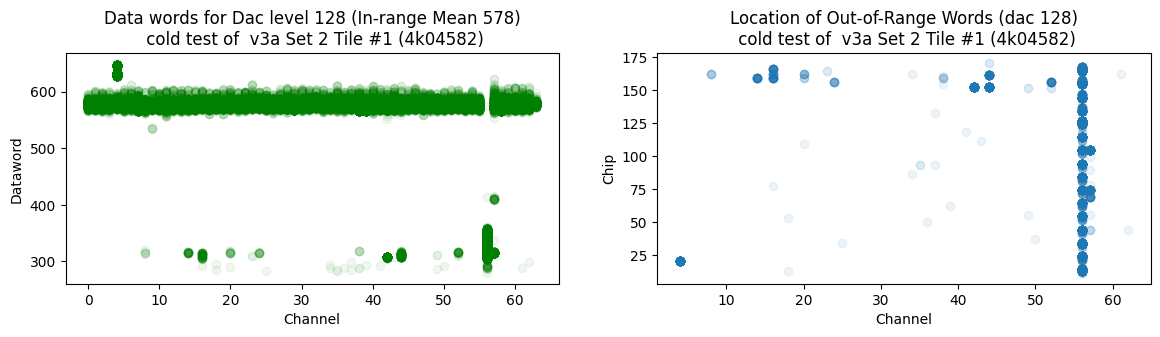

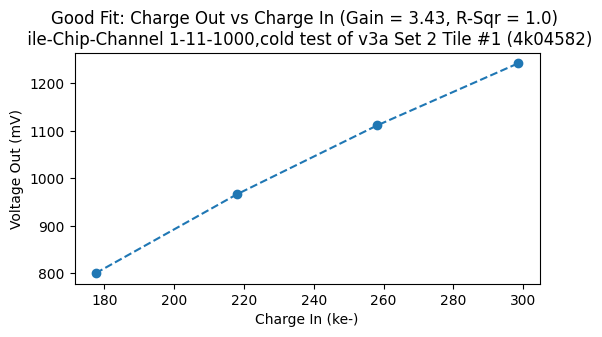

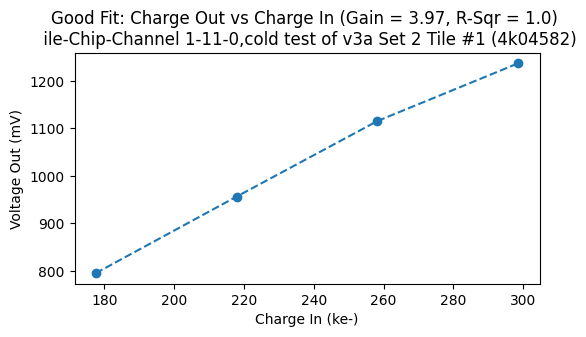

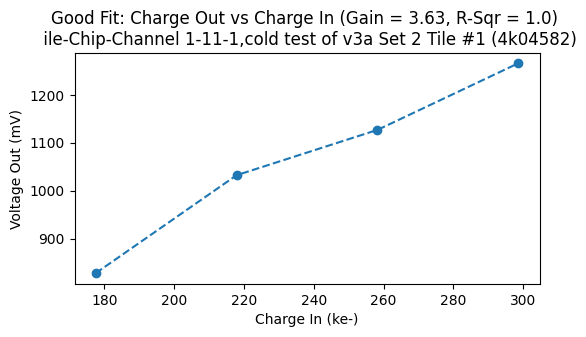

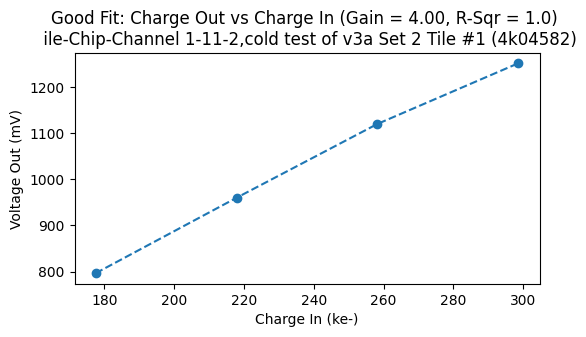

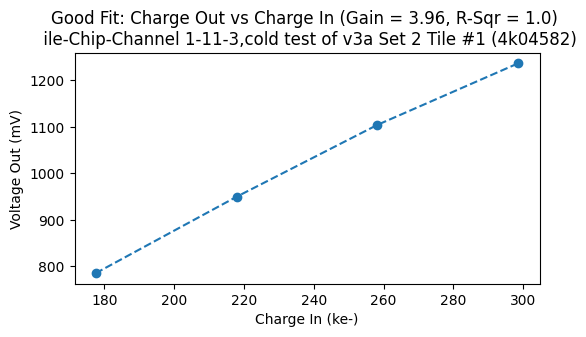

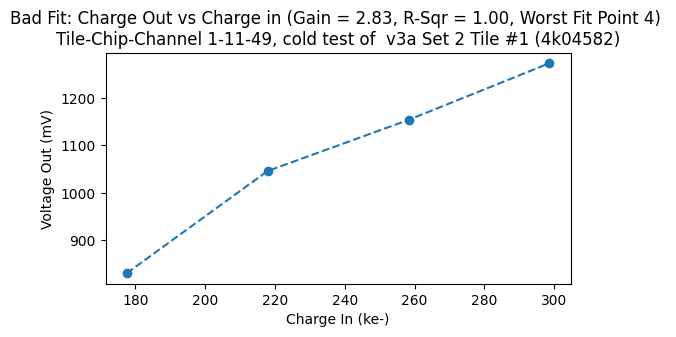

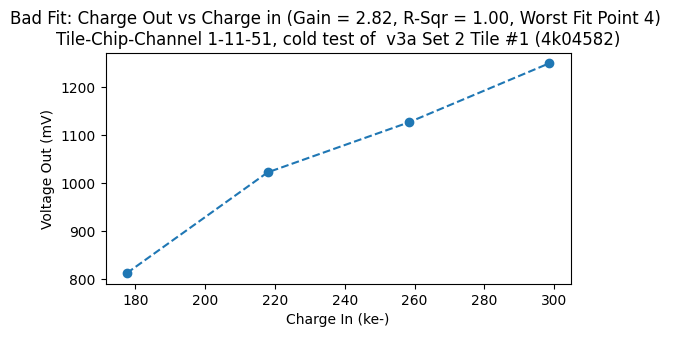

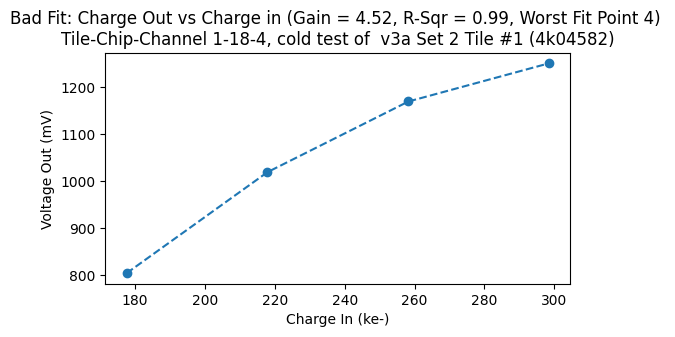

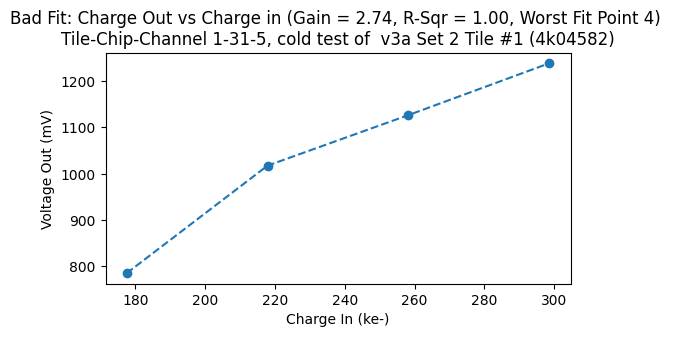

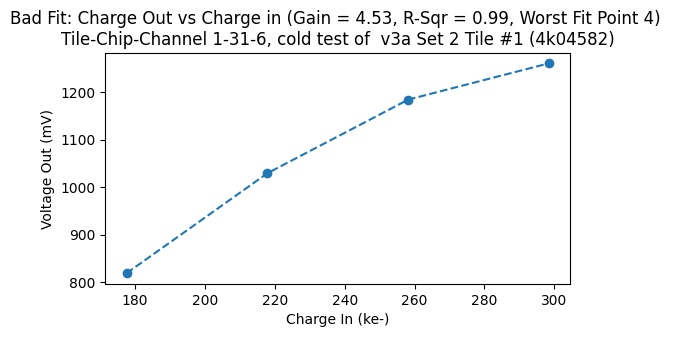

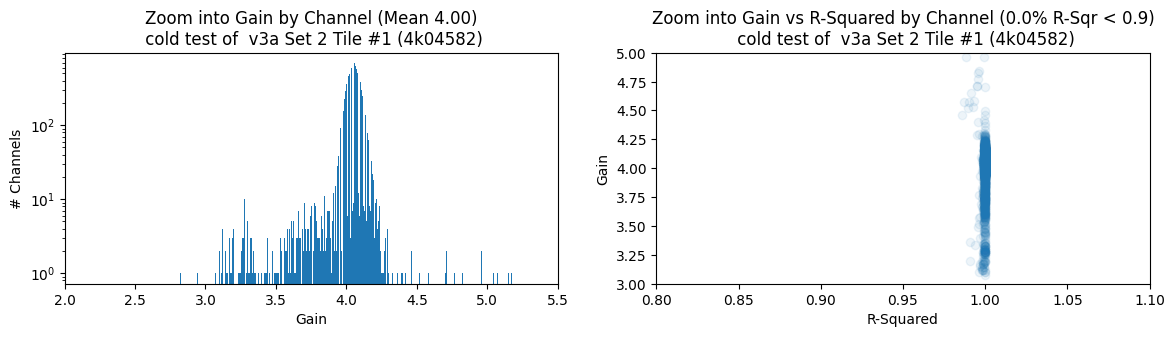

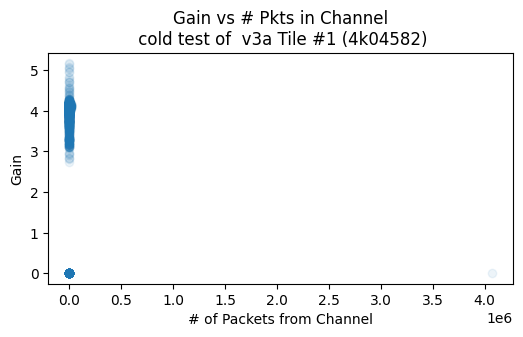

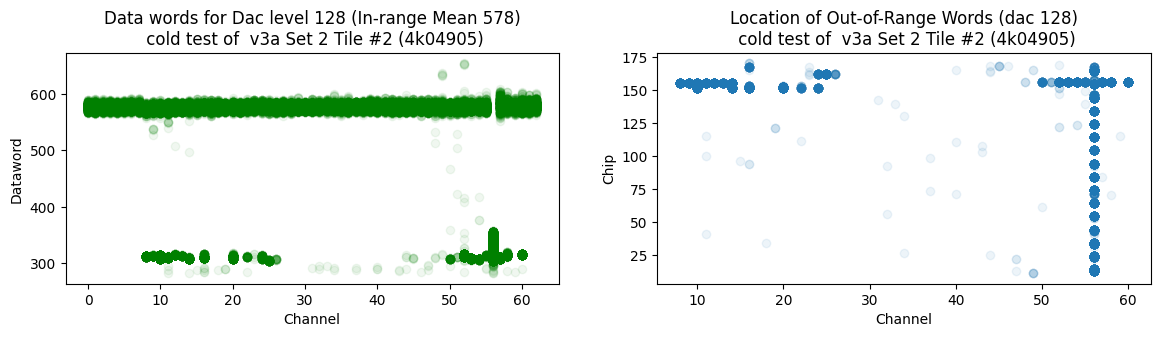

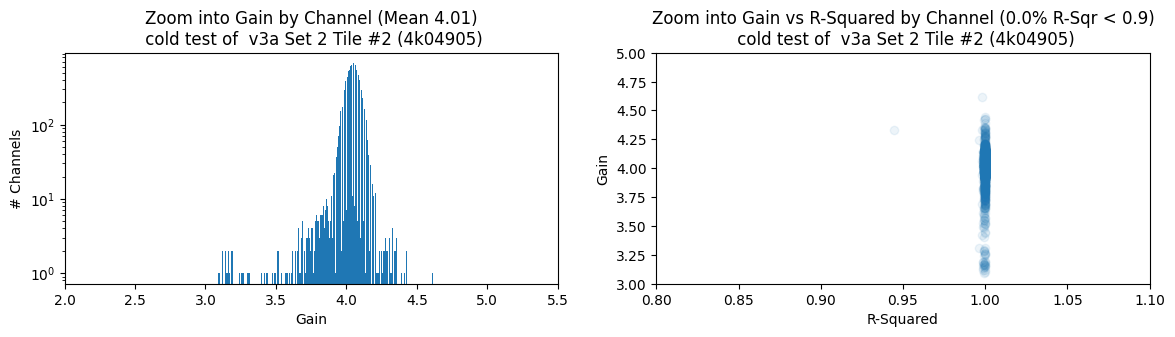

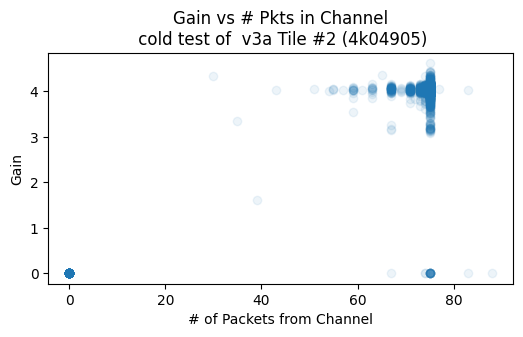

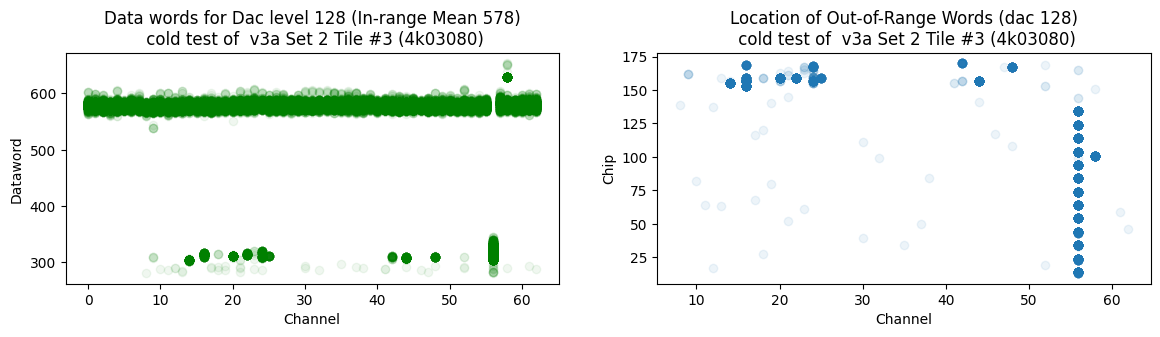

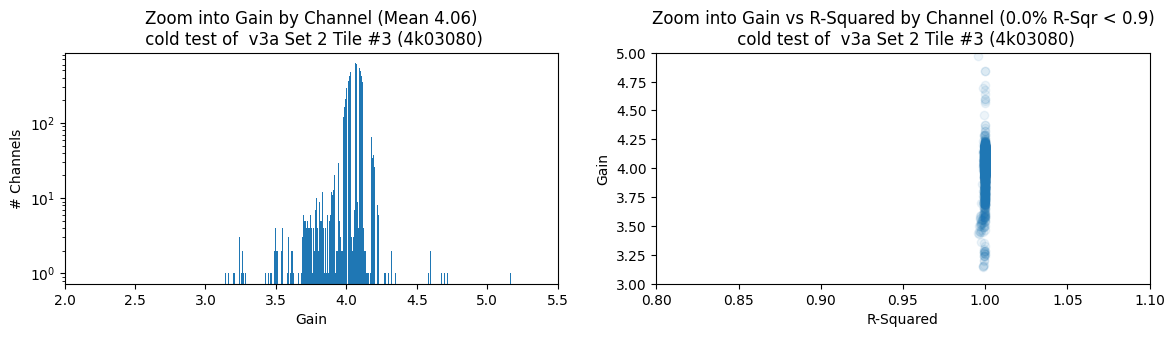

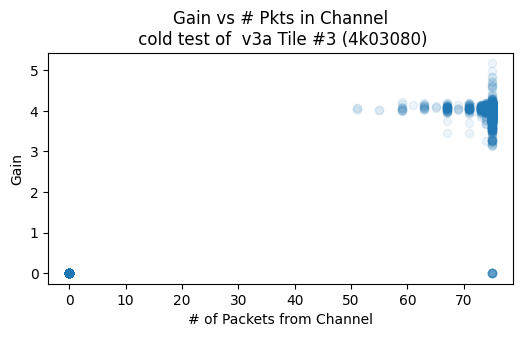

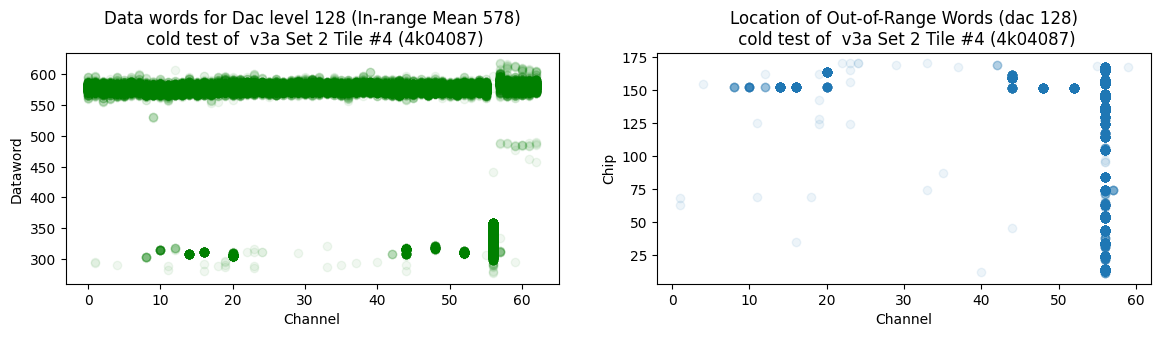

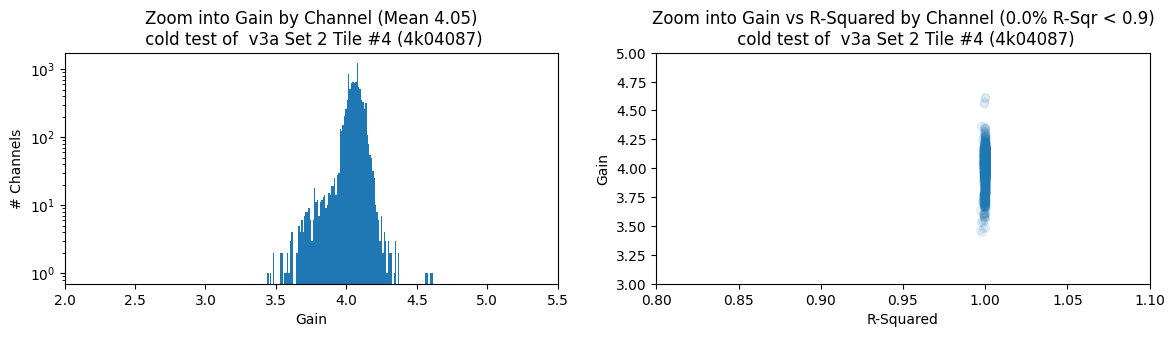

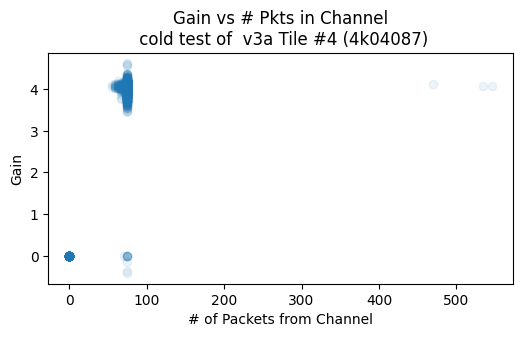

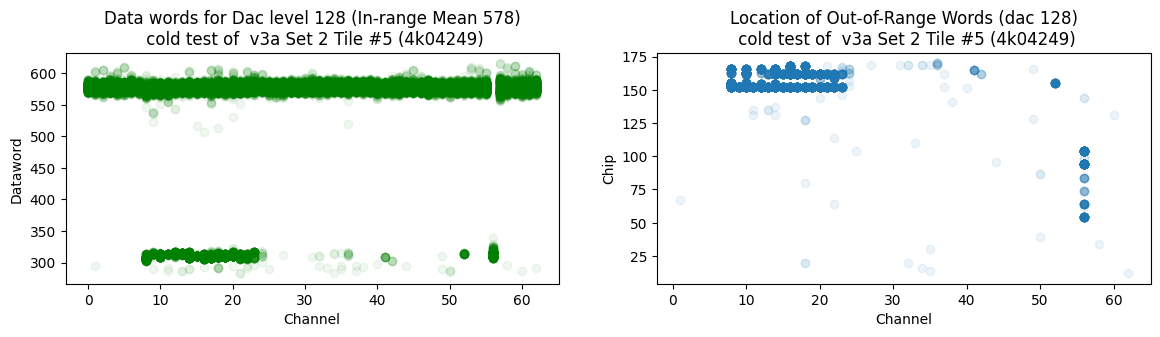

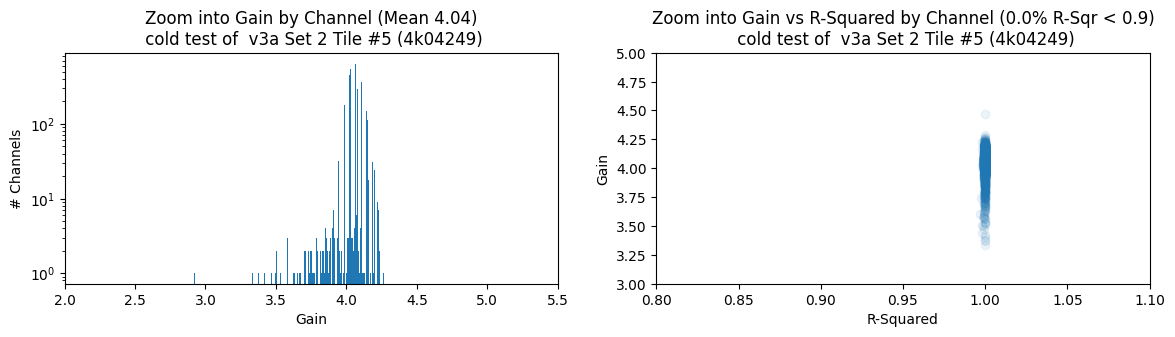

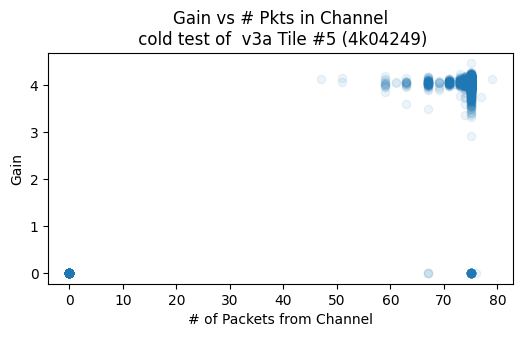

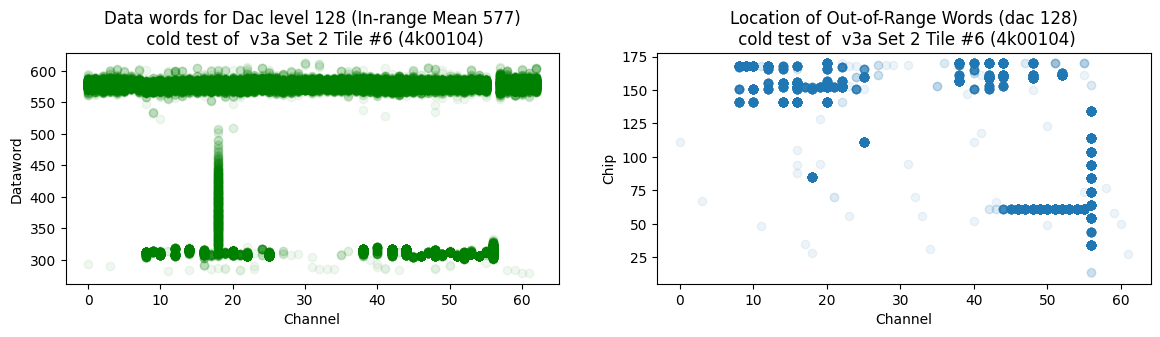

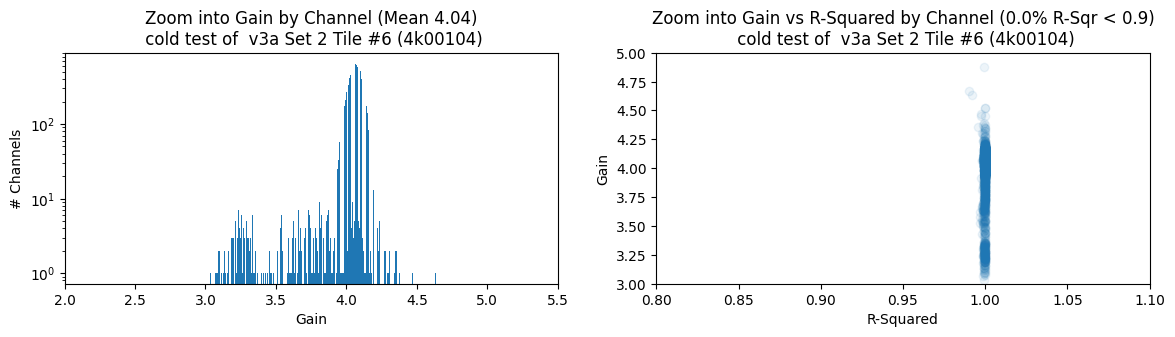

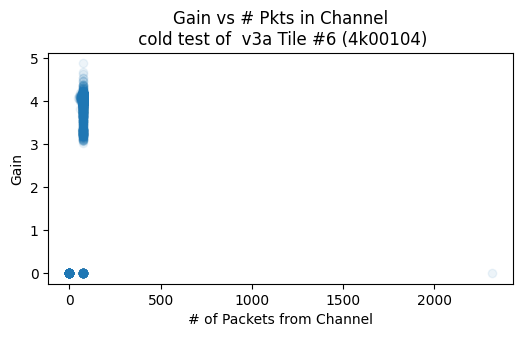

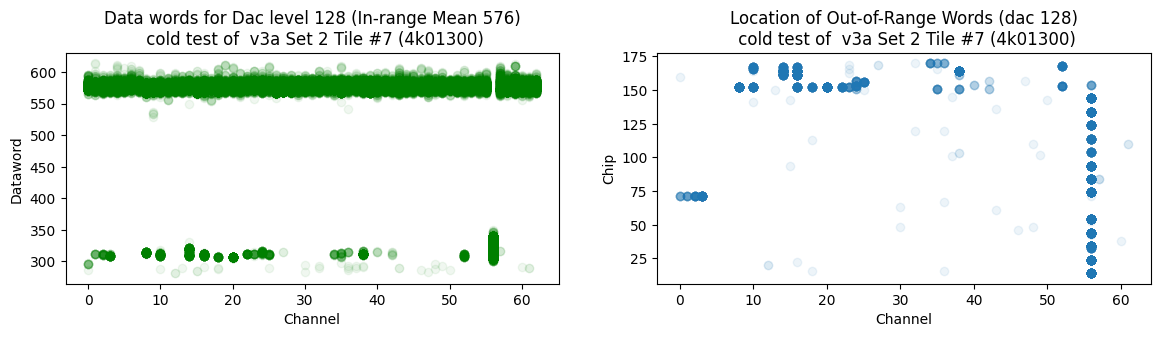

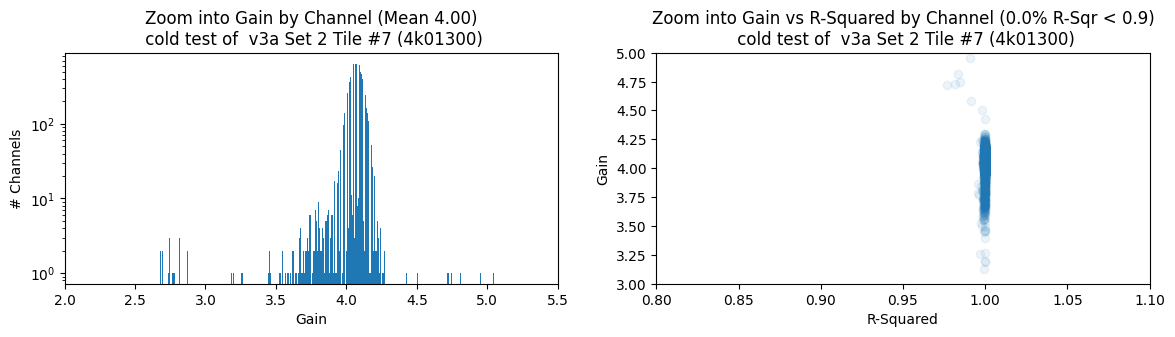

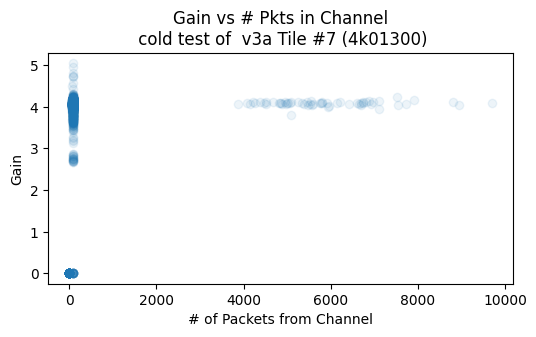

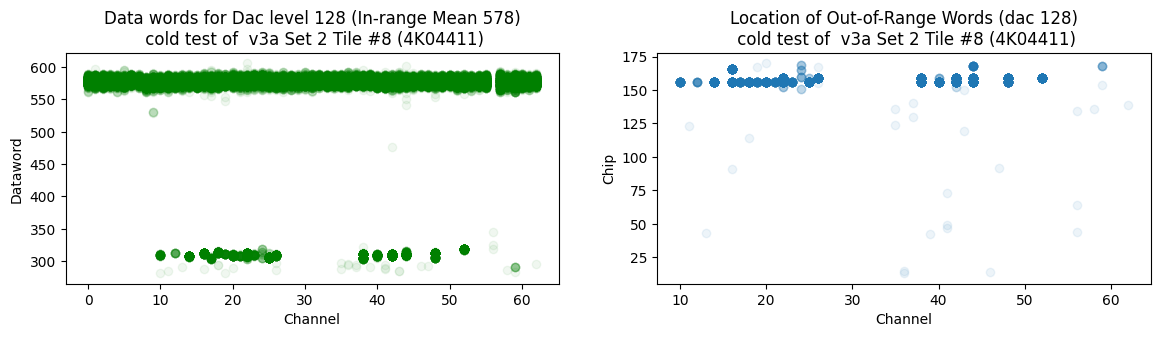

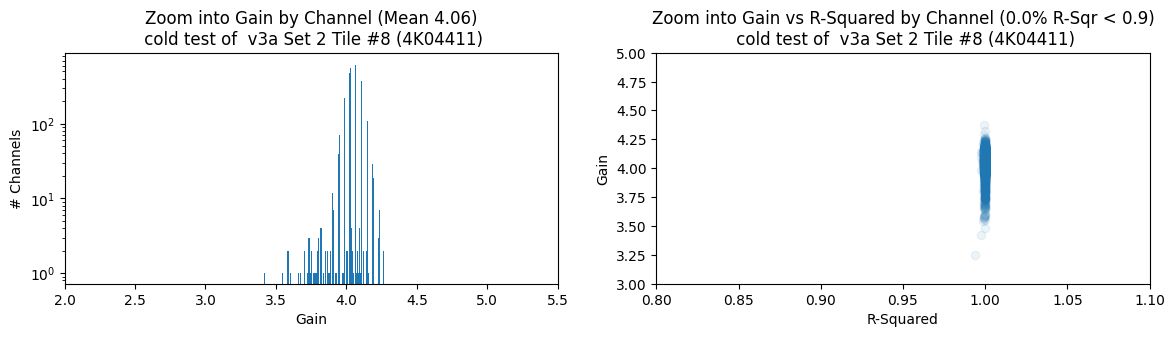

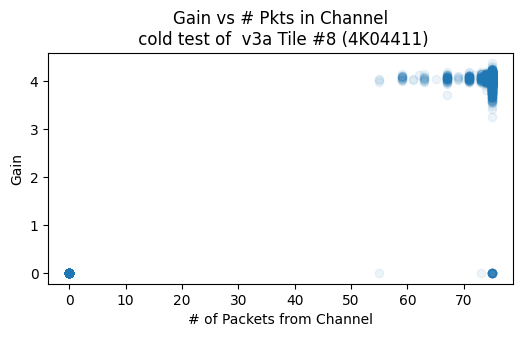

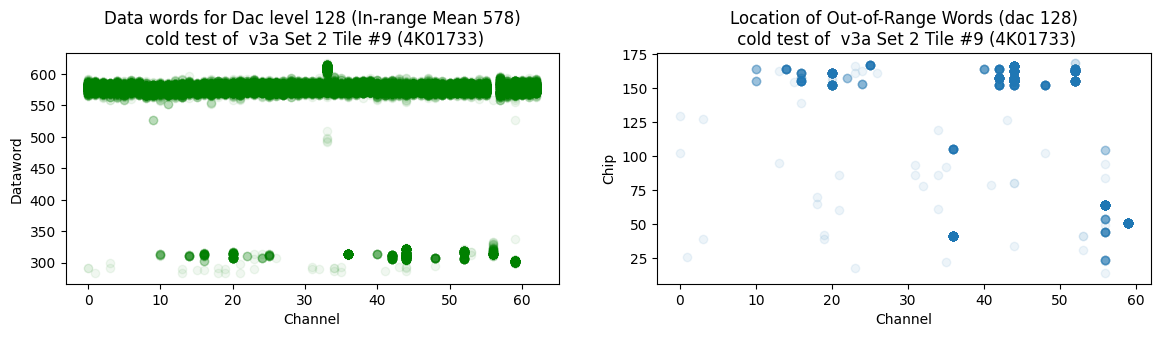

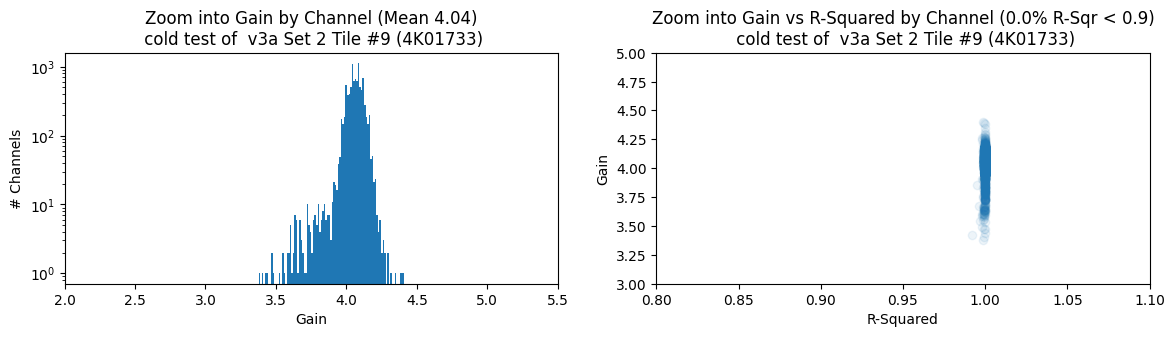

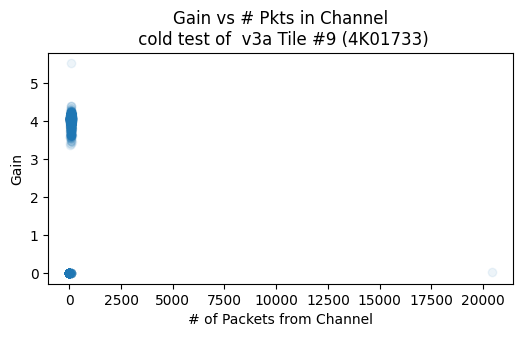

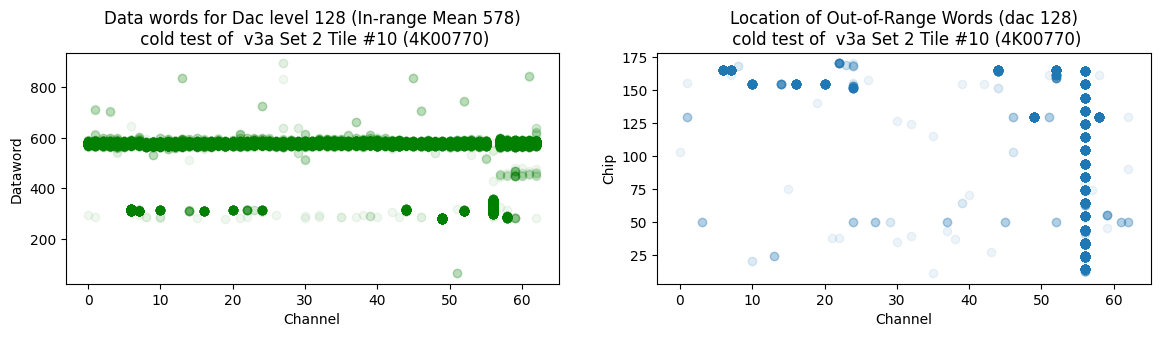

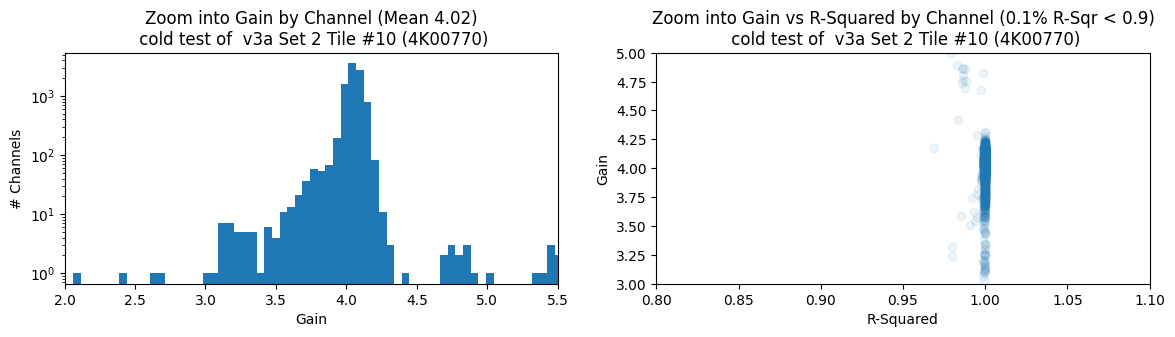

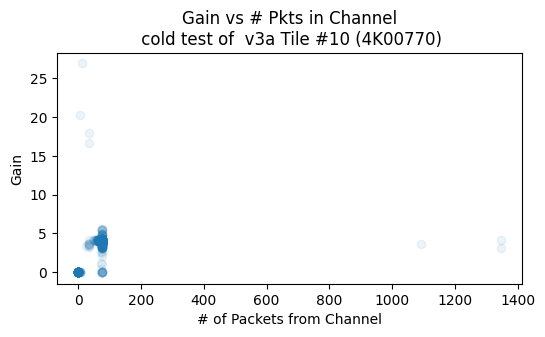

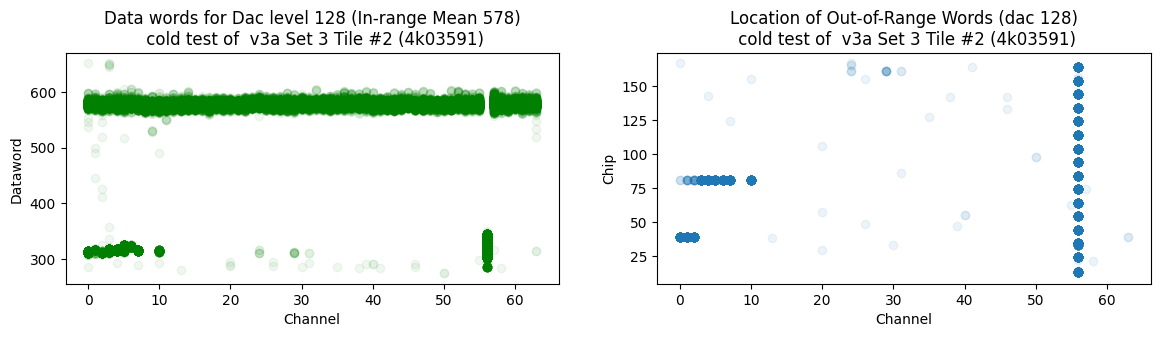

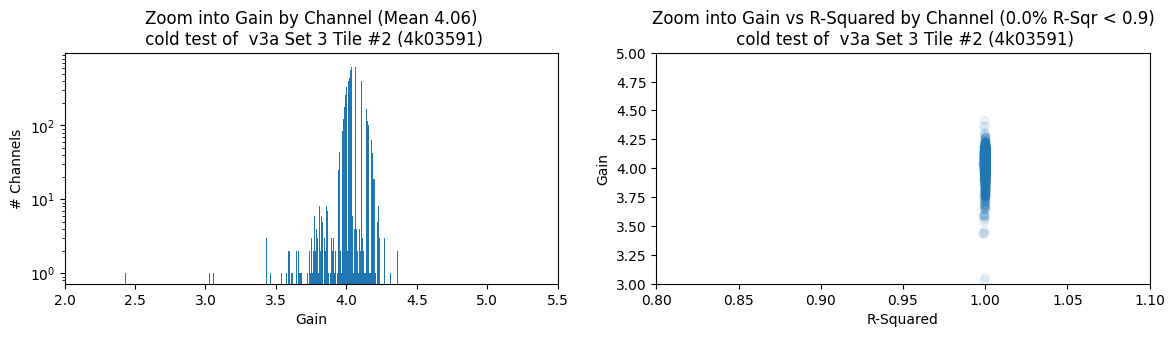

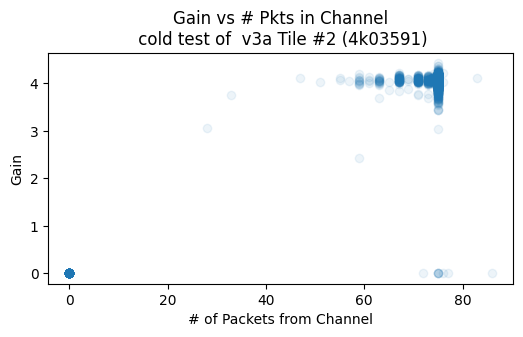

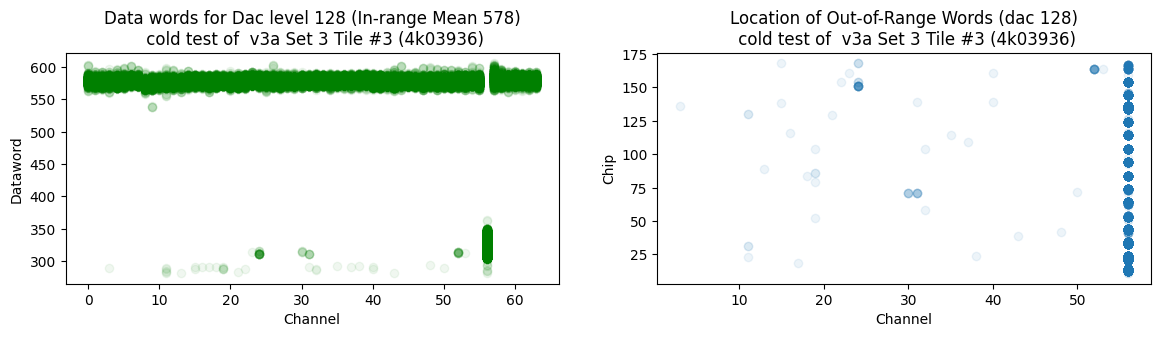

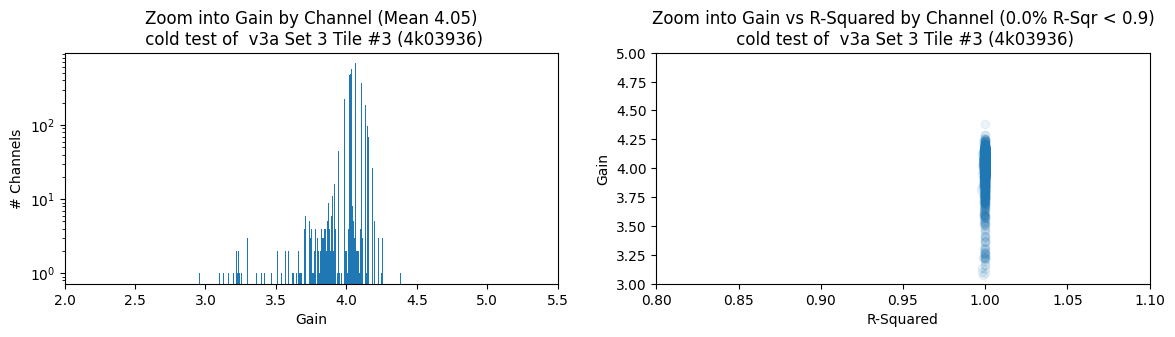

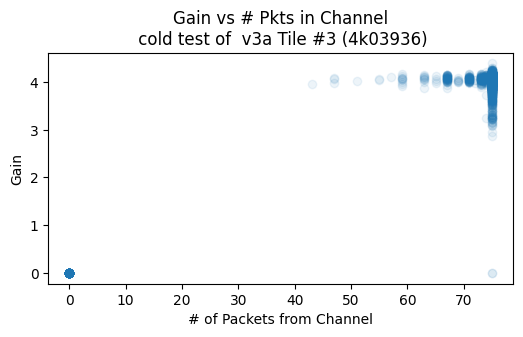

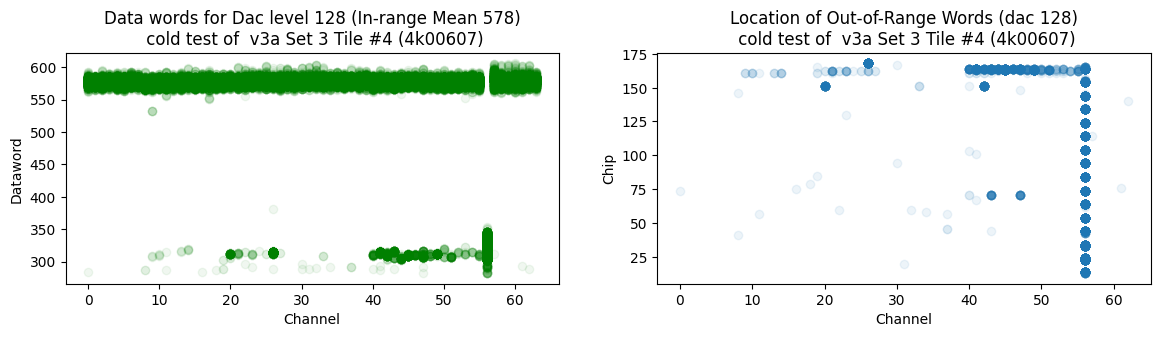

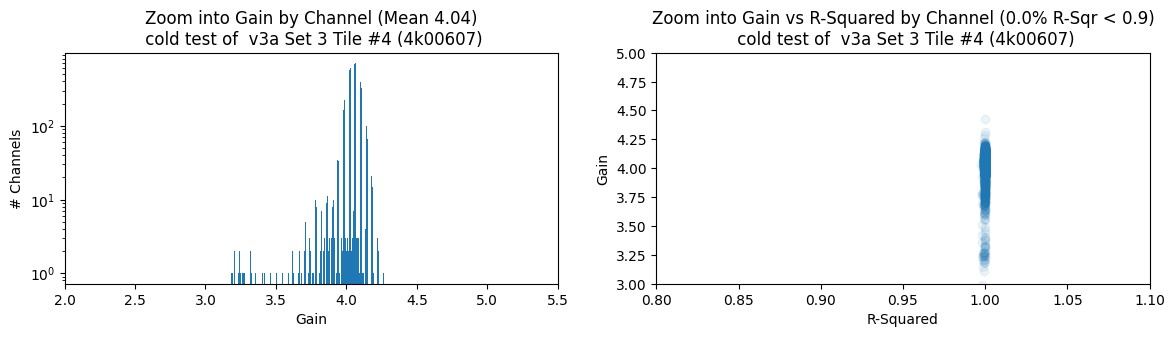

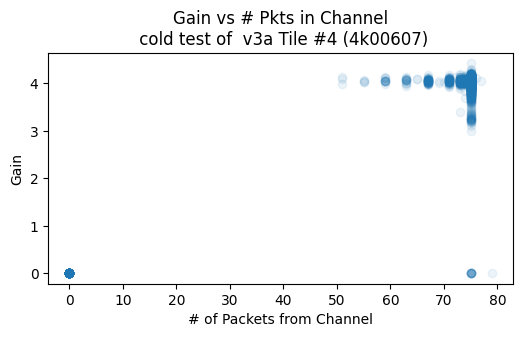

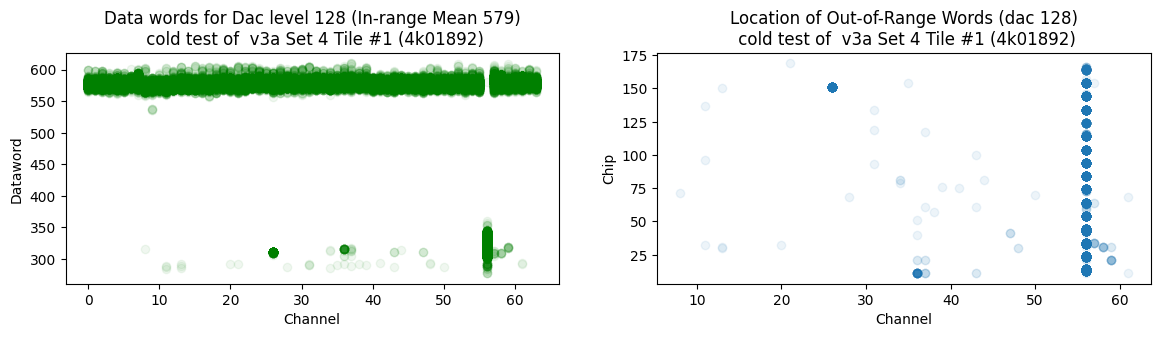

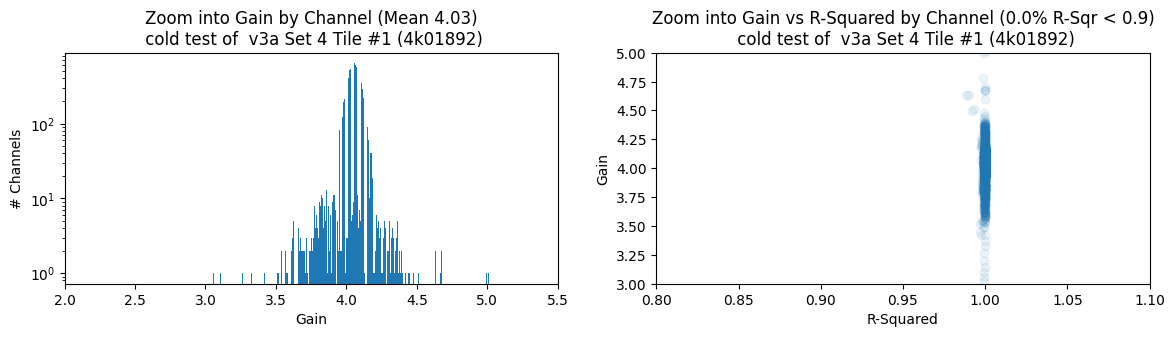

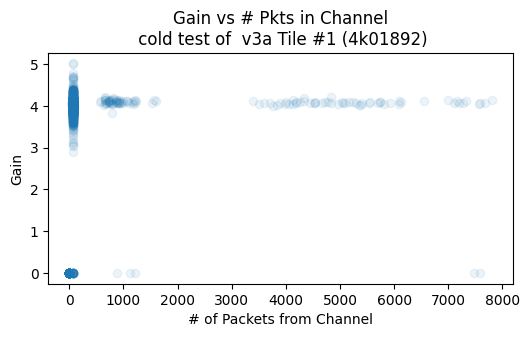

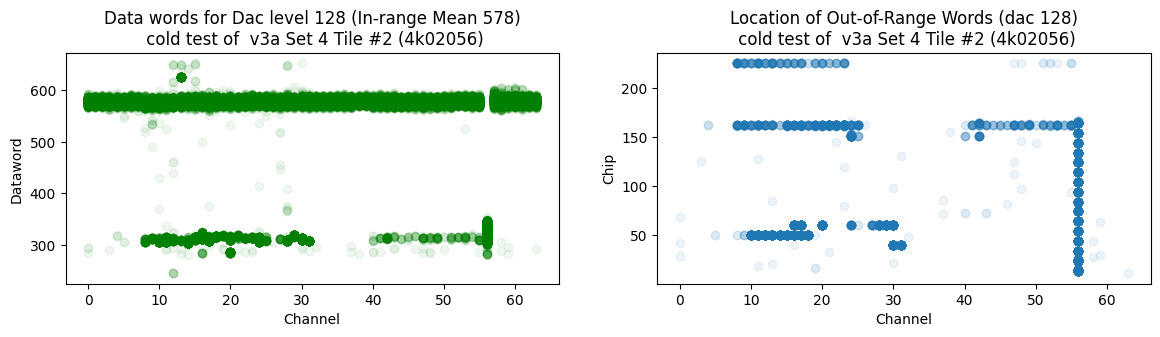

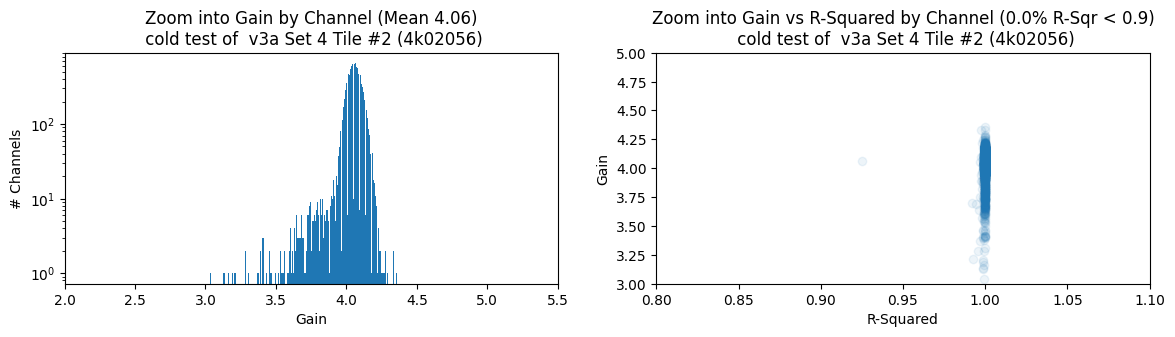

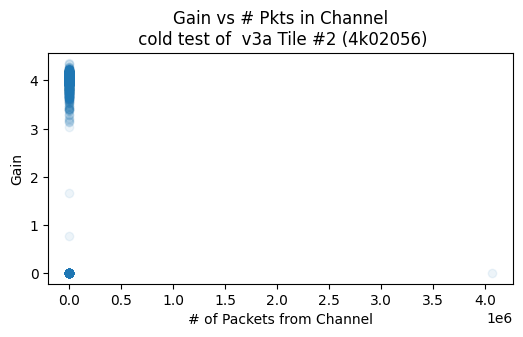

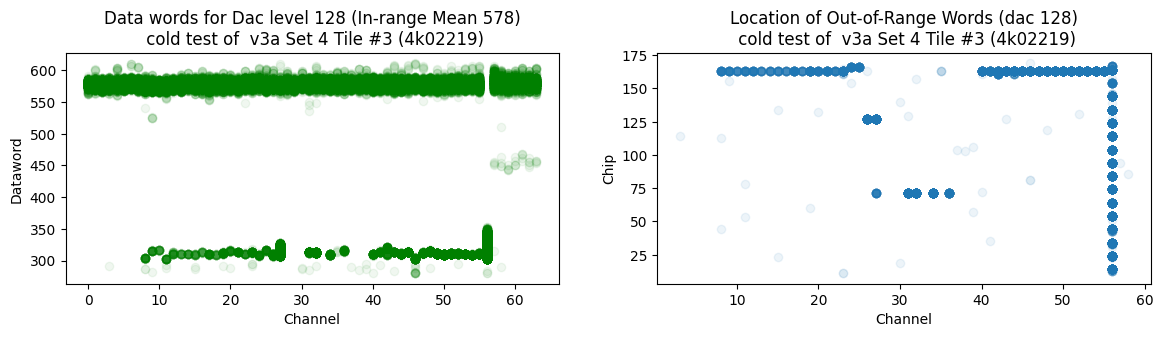

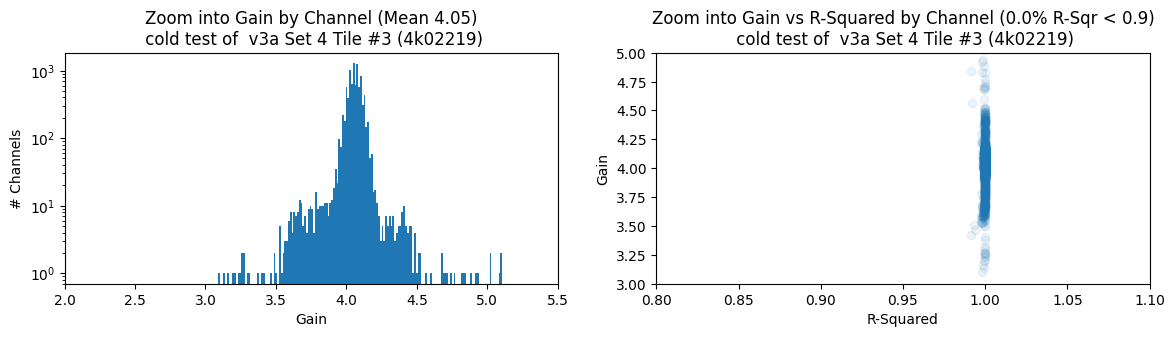

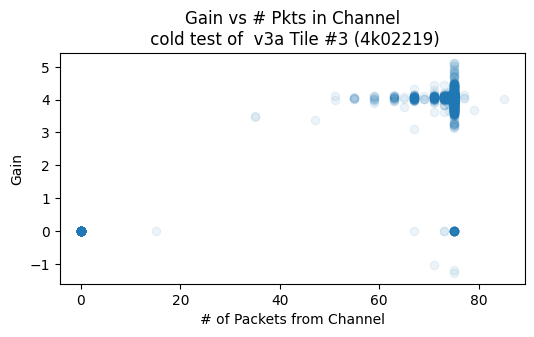

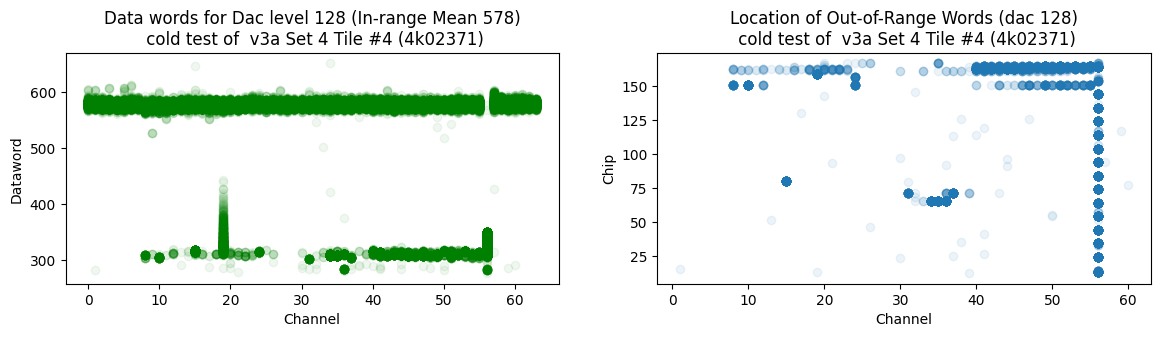

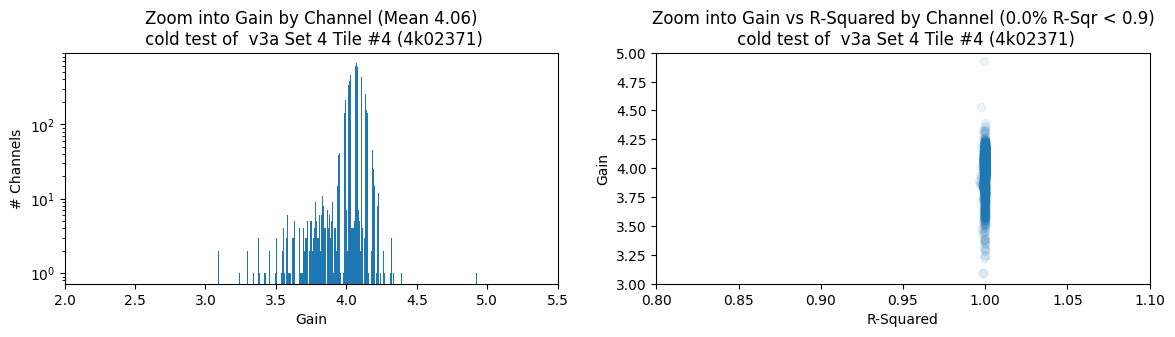

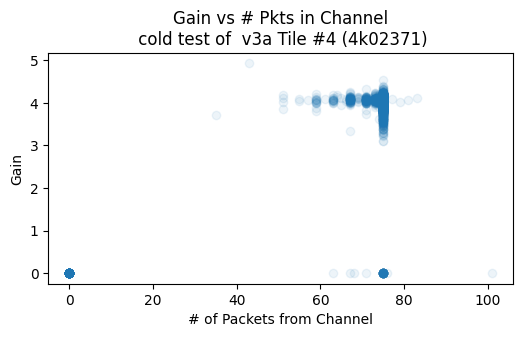

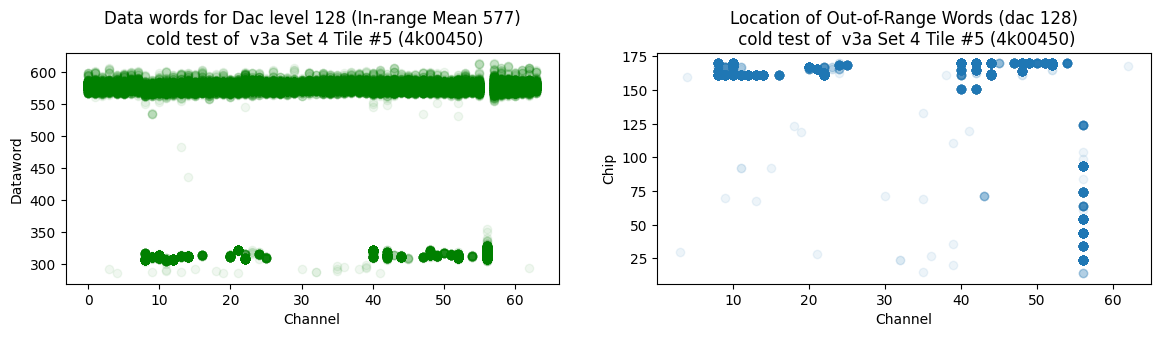

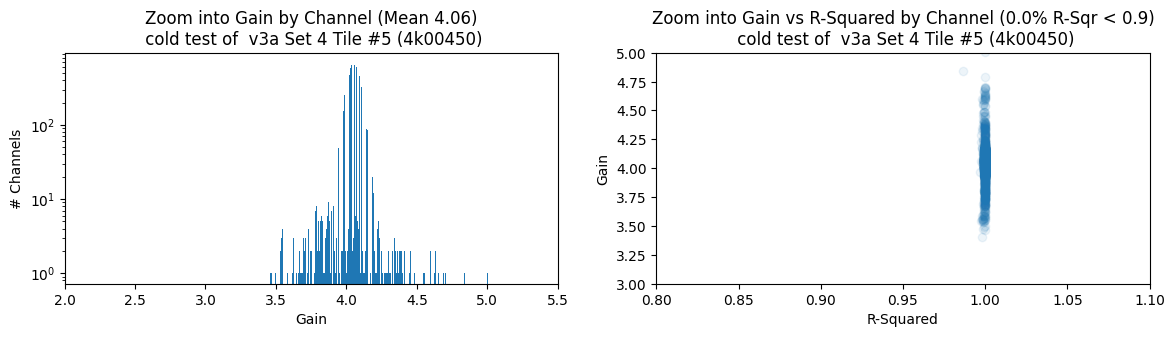

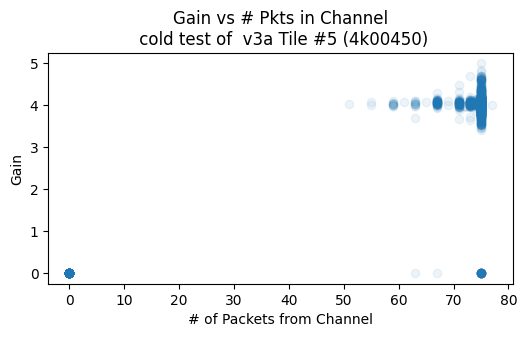

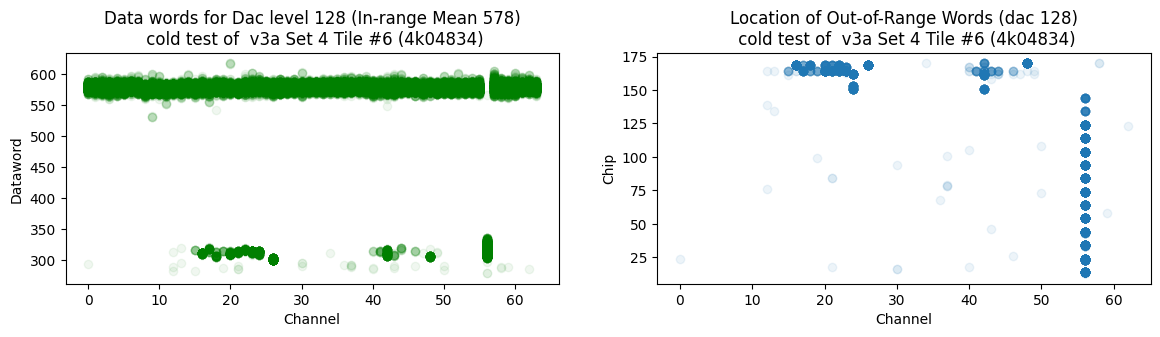

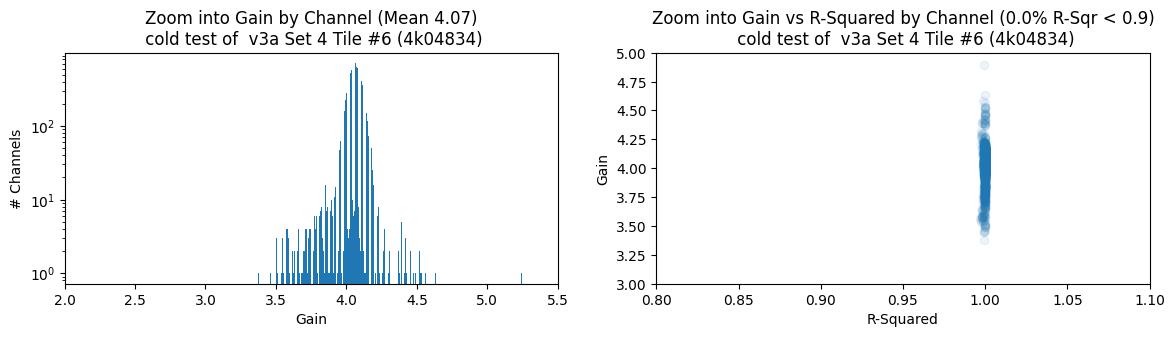

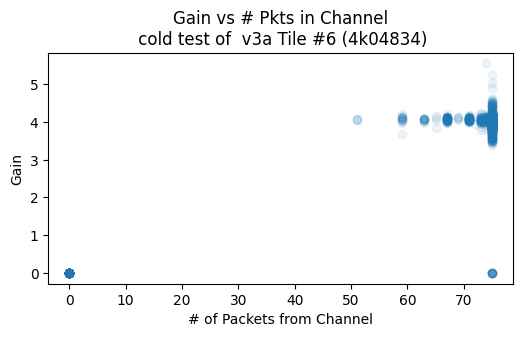

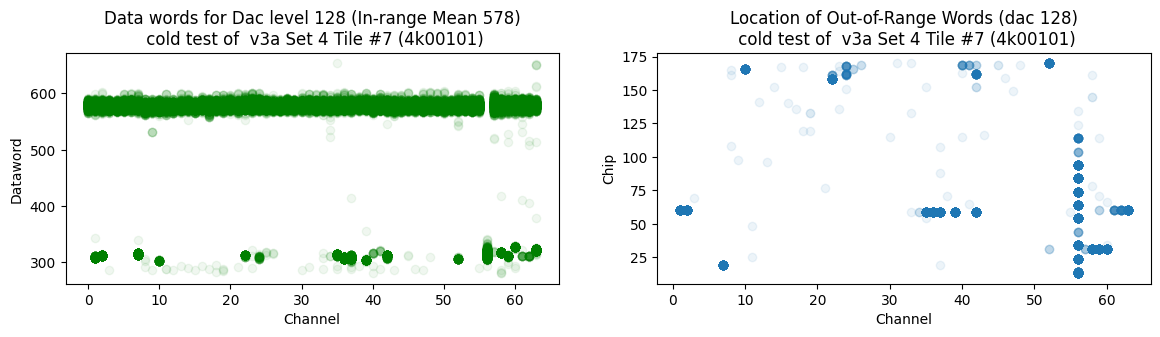

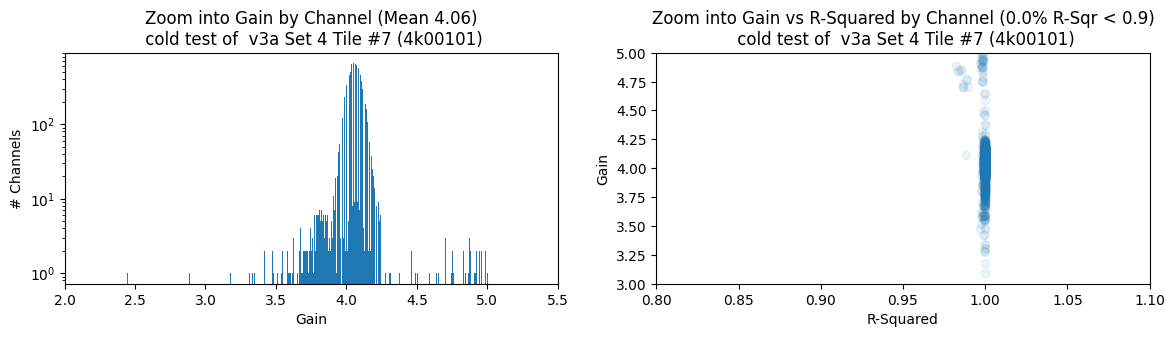

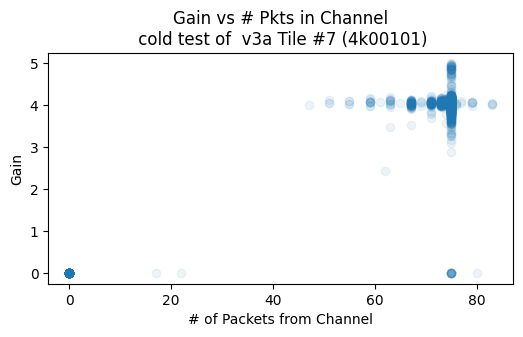

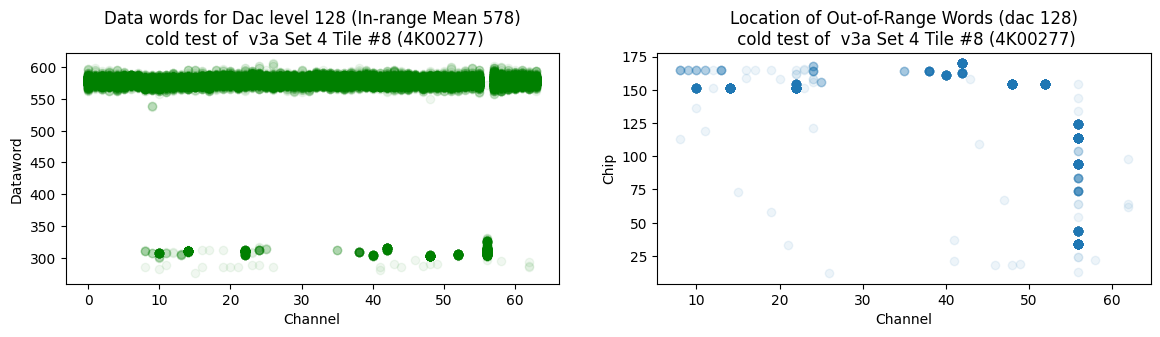

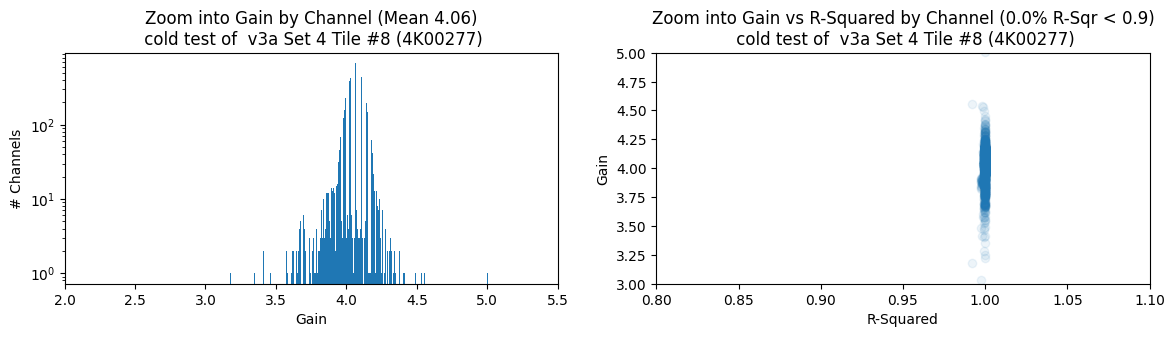

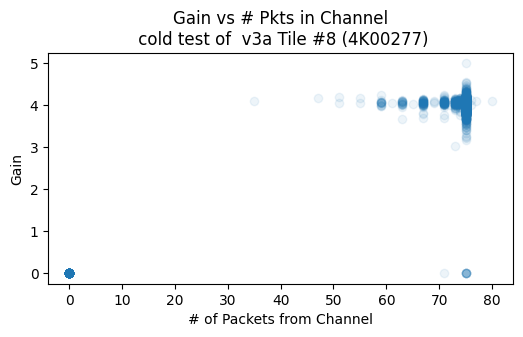

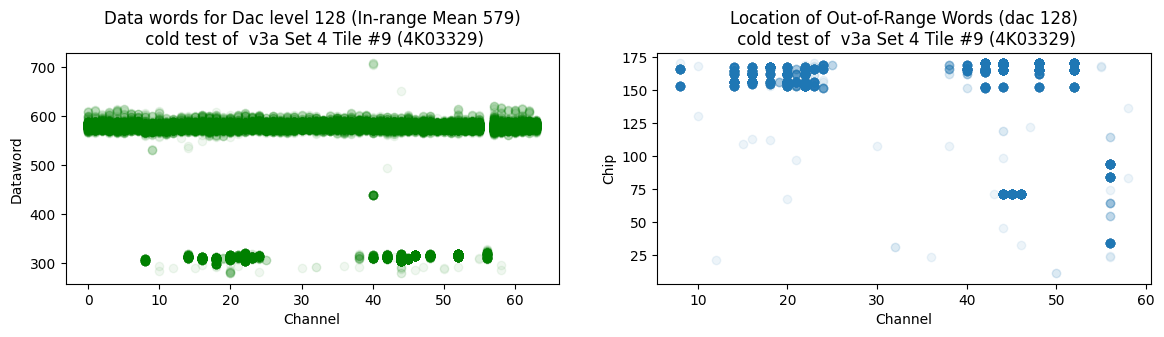

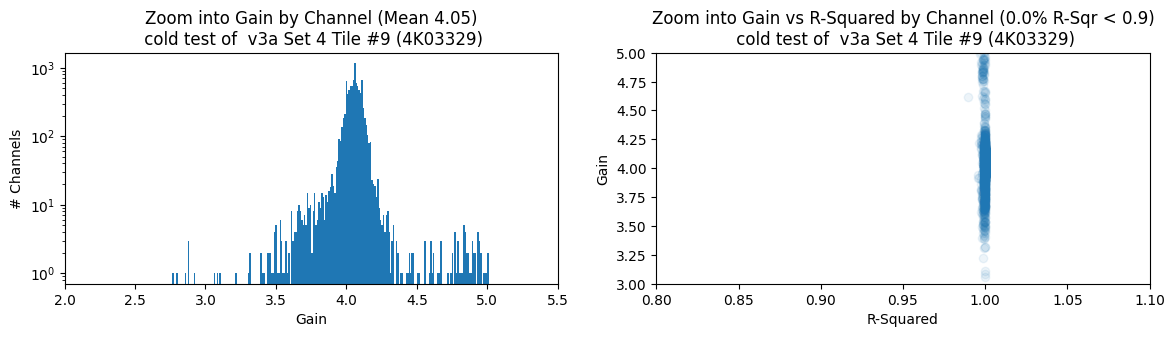

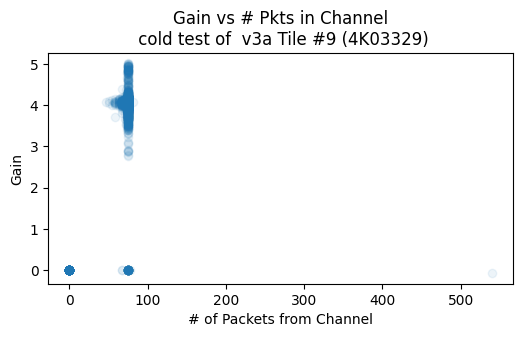

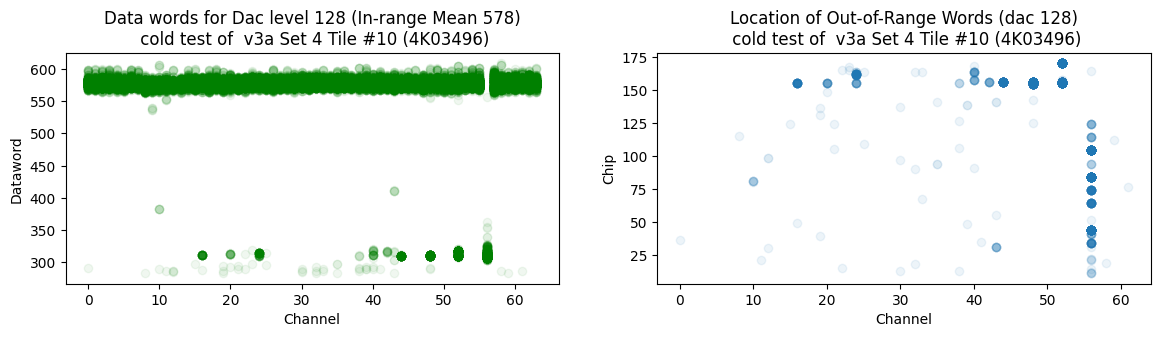

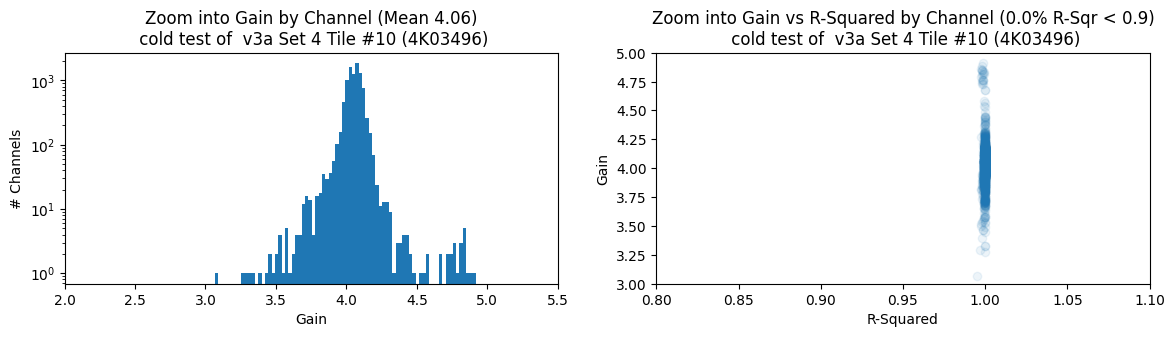

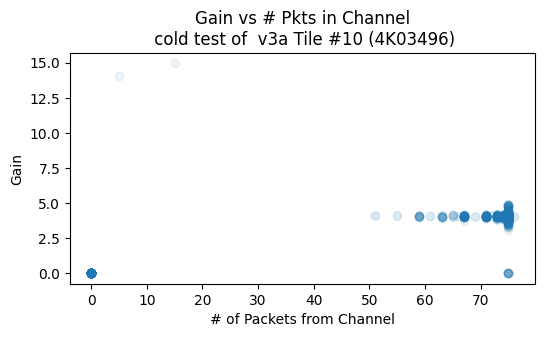

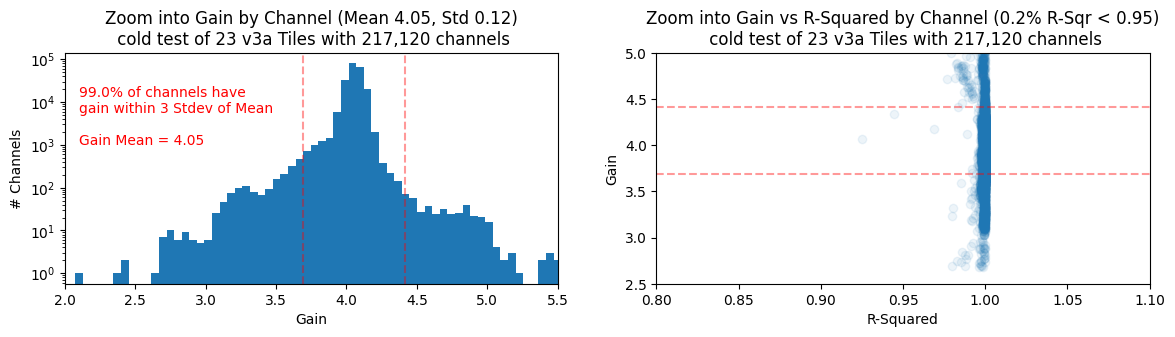

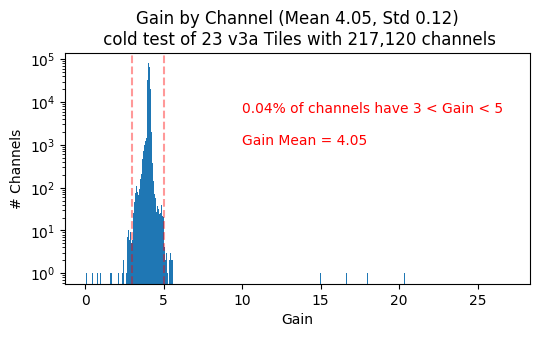

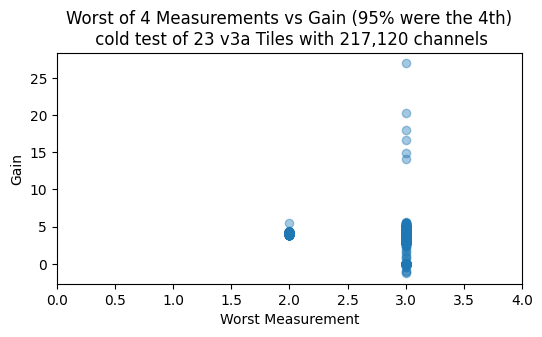

In [15]:
####################
# main
####################

print(f"On each chip, channels {omitted_channels} will be omitted from the results")

# import the results dictionary that holds all test results for all tiles at the chmannel level 
import_results_dictionary()

for setn in sets: 

    files = file_sets[setn-2]

    print(f'Run Statistics for {len(files)} Data Files:')

    for tile in tile_sets[setn-2]:

        print(f"\n\n********************* Results for Set {setn} Tile {tile} **************************\n")
        
        # initialize
        pkt_count   =  [[0 for chn in range(64)] for chp in range(256)]
        n_bad_words =  [[0 for chn in range(64)] for chp in range(256)]
        mean_chip   =  [[0 for dac in range(n_dacs)] for chip in range(256)] 
        mean_chan   = [[[0 for dac in range(n_dacs)] for chan in range(64) ] for chip in range(256)] 
        
        gain_chip = [0 for chip in range(171)]
        gain_chan = [[0 for chan in range(64)] for chip in range(171)]
        rsqr_chip = [0 for chip in range(171)]
        rsqr_chan = [[0 for chan in range(64)] for chip in range(171)]

        ntiles +=1
        
        chip_serial_number = chip_serial_number_list[setn-2][tile-1]

        get_data(setn, files, tile)

        calculate_all_gains(setn, tile, mean_chip, mean_chan)
        
        graph_gains(gain_chip, gain_chan, rsqr_chip, rsqr_chan, setn, tile, chip_serial_number)

# store the results from this file in the results dictionary for all tiles
store_results()

graph_all_gains()

0.26% of channels were filtered out because they were hot or had too many out-of-range words. 
	 This percentage does not include ommitted channels [56, 57, 58, 59, 63]
Gain Mode = 4.06, Gain Mean = 4.05, Gain Stdev = 0.12

0.23% of channels had R-Squared < 0.95 (491 channels out of 216562)

99.0% of channels have a gains within 3 stdev of mean


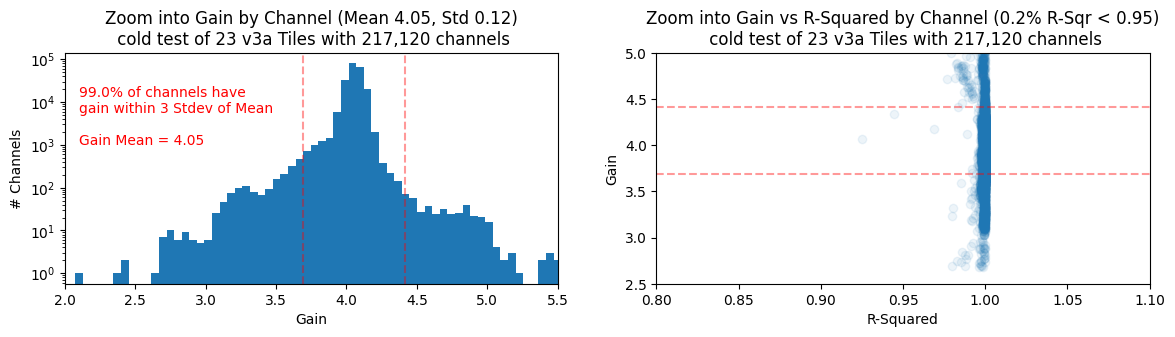

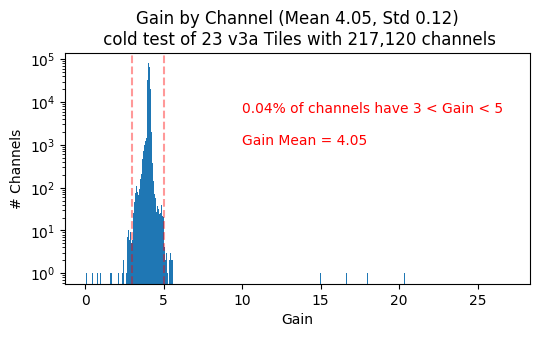

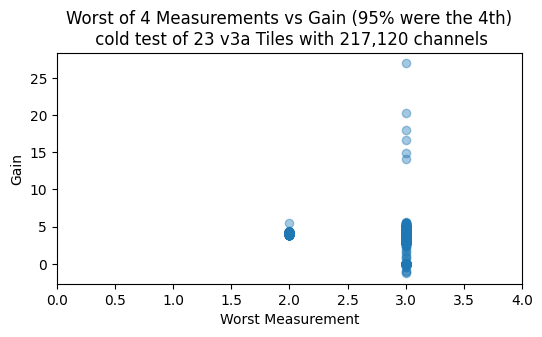

In [16]:
graph_all_gains()